# SAAM Project - Pacific Region

Sustainable & Active Asset Management - portfolio construction with carbon constraints.

This notebook is fully self-contained: it reads the project input files directly from `data/` and produces every table in `outputs/tables/` and every figure in `outputs/figures/`. It does **not** import anything from `src/`. The methodology follows the project PDF and the existing src reference code (MVP-construction, 05_part3.py, 06_part4.py).

Structure:
1. Setup
2. Short introduction
3. Data loading and cleaning
4. Part 1 - Minimum-Variance Portfolio (P_mv)
5. Part 2 - Value-Weighted benchmark (P_vw)
6. Part 3 - 50% carbon-footprint reduction (P_mv_50, P_vw_50)
7. Part 4 - Net-Zero trajectory (P_vw_NZ)
8. Final performance summary
9. Short conclusion

## 1. Setup

Imports, robust pathlib paths, methodology constants, and output folders.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# project paths
ROOT = Path.cwd()
if ROOT.name == "src":
    ROOT = ROOT.parent
DATA = ROOT / "data"
RAW = DATA / "raw"
PROCESSED = DATA / "processed"
OUTPUTS = ROOT / "outputs"
TABLES = OUTPUTS / "tables"
FIGURES = OUTPUTS / "figures"
for d in (OUTPUTS, TABLES, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

# methodology constants (identical to the src reference)
YEAR_FIRST = 2013      # first allocation year (decision at end of Y)
YEAR_LAST = 2024       # last allocation year -> implementation Y+1 = 2025
PERF_START = 2014      # first implementation year (inclusive)
PERF_END = 2025        # last implementation year (inclusive)
ESTIM_MONTHS = 120     # 10-year rolling estimation window
MIN_OBS = 36           # >= 3 years of returns in the window
STALE_THRESHOLD = 0.50 # <= 50% zero returns in the window
RIDGE_EPS = 1e-6       # ridge added to Sigma
THETA_NZ = 0.10        # 10% per year carbon decay (Part 4)
CARBON_SCOPE = "scope1" # assigned climate strategy for this group

pd.options.display.float_format = "{:,.4f}".format
print("Setup OK. ROOT =", ROOT)

def file_inventory(folder):
    """Return a notebook-friendly inventory of files under a folder."""
    rows = []
    for path in sorted(folder.rglob("*")):
        if path.is_file():
            rows.append({
                "folder": str(path.parent.relative_to(ROOT)),
                "file": path.name,
                "relative_path": str(path.relative_to(ROOT)),
                "size_kb": path.stat().st_size / 1024.0,
            })
    return pd.DataFrame(rows)

input_files = pd.concat([file_inventory(RAW), file_inventory(PROCESSED)], ignore_index=True)
print("Input files available to this notebook:")
display(input_files)

Setup OK. ROOT = /Users/yazidabaroudi/SAAM-Project-1/SAAM_final_notebook_package
Input files available to this notebook:


,folder,file,relative_path,size_kb
0,data/raw,DS_MV_T_USD_M.csv,data/raw/DS_MV_T_USD_M.csv,"6,154.5371"
1,data/raw,DS_MV_T_USD_Y.csv,data/raw/DS_MV_T_USD_Y.csv,592.2803
2,data/processed,Clean_CO2_Scope1_Pacific.csv,data/processed/Clean_CO2_Scope1_Pacific.csv,65.6357
3,data/processed,Clean_Prices_Pacific.csv,data/processed/Clean_Prices_Pacific.csv,904.7061
4,data/processed,Clean_Revenues_Pacific.csv,data/processed/Clean_Revenues_Pacific.csv,146.1826
5,data/processed,Pacific_Universe.csv,data/processed/Pacific_Universe.csv,18.0195
6,data/processed,rf_rate.csv,data/processed/rf_rate.csv,3.5850


## 2. Short introduction

We build five portfolios on the Pacific equity universe and compare their financial **and** carbon performance over 2014-2025:

- **P_vw**: market-cap weighted benchmark, monthly rebalanced (Section 2.3).
- **P_mv**: long-only minimum-variance portfolio, annually rebalanced, intra-year drift (Section 2.2).
- **P_mv_50**: minimum variance with carbon footprint capped at 50% of P_mv (Section 3.2).
- **P_vw_50**: tracking-error minimisation vs P_vw with the same 50% CF cap (Section 3.3).
- **P_vw_NZ**: tracking-error minimisation vs P_vw with a declining Net-Zero cap, -10% per year from the 2013 anchor (Section 4).

Carbon metrics:
- WACI = $\sum_i w_i\, \text{CI}_i$ with $\text{CI}_i = E_i / (\text{Rev}_i / 1000)$ (tCO2e per M$ revenue).
- Carbon Footprint CF = $\sum_i w_i \, (E_i / \text{Cap}_i)$ (tCO2e per M$ invested).

Why it matters: investors want low risk and exposure to the climate transition. Comparing constrained portfolios to unconstrained ones shows the financial *cost*, or *absence of cost*, of decarbonisation.

## 3. Data loading and cleaning

The notebook is designed to run from a minimal hand-in folder containing only this notebook, `requirements.txt`, and the required `data/` files. It does not import `src/` files and it does not read from `Archives/`.

Cleaning rules applied here:
- filter the Static/Pacific universe file to the assigned Pacific region when a raw Static file is available,
- otherwise use the already Pacific-filtered universe file in `data/processed`,
- convert Datastream error strings and non-numeric values to `NaN`,
- set total return index prices below 0.5 to `NaN`,
- compute simple monthly returns as `P_t / P_{t-1} - 1`,
- treat delistings as a `-100%` return in the first month after the last valid price, then `NaN` afterwards,
- convert the risk-free rate file into the two-column format expected by this notebook.

The portfolio construction remains fully inside this notebook: `build_year_inputs(year)` controls yearly eligibility, rolling covariance estimation, carbon/revenue/market-cap alignment, and annual value-weighted benchmark construction.


In [2]:
# Data-only loaders for the minimal hand-in folder.
def first_existing(paths):
    for path in paths:
        path = Path(path)
        if path.exists():
            return path
    return None


def read_table(path):
    path = Path(path)
    if path.suffix.lower() in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    return pd.read_csv(path)


def normalise_static_columns(df):
    rename = {}
    for col in df.columns:
        low = str(col).strip().lower()
        if low == "isin":
            rename[col] = "ISIN"
        elif low in {"name", "company name"}:
            rename[col] = "NAME"
        elif low == "country":
            rename[col] = "Country"
        elif low == "region":
            rename[col] = "Region"
    return df.rename(columns=rename)


def build_pacific_universe():
    static_path = first_existing([
        RAW / "Static_2025.xlsx",
        RAW / "Static.xlsx",
        RAW / "Static.csv",
        PROCESSED / "Pacific_Universe.csv",
        PROCESSED / "static_pac.csv",
    ])
    if static_path is None:
        raise FileNotFoundError("No Static or Pacific universe file found in data/")

    static_raw = normalise_static_columns(read_table(static_path))
    if "Region" in static_raw.columns:
        pac = static_raw[static_raw["Region"].astype(str).str.strip().eq("PAC")].copy()
    else:
        # Already Pacific-filtered helper file, e.g. Pacific_Universe.csv or static_pac.csv.
        pac = static_raw.copy()
        pac["Region"] = "PAC"

    keep = [c for c in ["ISIN", "NAME", "Country", "Region"] if c in pac.columns]
    pac = pac[keep].dropna(subset=["ISIN"]).drop_duplicates("ISIN")
    pac["ISIN"] = pac["ISIN"].astype(str)
    pac.to_csv(PROCESSED / "Pacific_Universe.csv", index=False)
    pac[[c for c in ["ISIN", "NAME", "Country"] if c in pac.columns]].to_csv(PROCESSED / "static_pac.csv", index=False)
    return pac


def read_wide(path, date_columns):
    """Read Datastream-style wide data with ISIN rows and periods in columns."""
    df = read_table(path)
    if "ISIN" not in df.columns:
        raise ValueError(f"{path} does not contain an ISIN column")
    df = df[df["ISIN"].notna()].copy()
    df["ISIN"] = df["ISIN"].astype(str)
    df = df.set_index("ISIN").drop(columns=["NAME"], errors="ignore")
    df = df.apply(pd.to_numeric, errors="coerce")
    if date_columns:
        df.columns = pd.to_datetime(df.columns).normalize()
    else:
        df.columns = df.columns.astype(int)
    return df


def read_processed_matrix(path, date_index=True):
    """Read helper-style processed matrices with date/year rows and ISIN columns."""
    df = pd.read_csv(path, index_col=0)
    df = df.apply(pd.to_numeric, errors="coerce")
    if date_index:
        df.index = pd.to_datetime(df.index).normalize()
    else:
        df.index = df.index.astype(int)
    return df


def read_panel(path, date_columns):
    """Return an ISIN x period panel from either raw wide files or processed helper matrices."""
    path = Path(path)
    preview = pd.read_csv(path, nrows=0) if path.suffix.lower() == ".csv" else pd.read_excel(path, nrows=0)
    if "ISIN" in preview.columns:
        return read_wide(path, date_columns=date_columns)
    return read_processed_matrix(path, date_index=date_columns).T


def require_file(label, paths):
    path = first_existing(paths)
    if path is None:
        searched = "\n".join(f"- {p}" for p in paths)
        raise FileNotFoundError(f"{label} not found in data/. Searched:\n{searched}")
    return path


static = build_pacific_universe()
name_col = "NAME" if "NAME" in static.columns else "Name"
names = static.set_index("ISIN")[name_col].astype(str)
countries = static.set_index("ISIN")["Country"].astype(str) if "Country" in static.columns else pd.Series(index=names.index, dtype=str)
pacific = set(static["ISIN"].astype(str))

# Monthly total return index prices. Prefer raw Datastream file; fall back to cleaned data/processed files.
price_path = require_file("Total return index price file", [
    RAW / "DS_RI_T_USD_M_2025.xlsx",
    RAW / "DS_RI_T_USD_M.xlsx",
    RAW / "DS_RI_T_USD_M.csv",
    PROCESSED / "prices_clean.csv",
    PROCESSED / "Clean_Prices_Pacific.csv",
])
prices_wide = read_panel(price_path, date_columns=True)
prices_wide = prices_wide.loc[prices_wide.index.intersection(pacific)]

# Scope 1 emissions. Do not apply a global missing-data filter here.
co2_path = require_file("Scope 1 emissions file", [
    RAW / "DS_CO2_SCOPE_1_Y_2025.xlsx",
    RAW / "DS_CO2_SCOPE_1.xlsx",
    RAW / "DS_CO2_SCOPE_1.csv",
    PROCESSED / "co2_scope1.csv",
    PROCESSED / "Clean_CO2_Scope1_Pacific.csv",
])
emissions = read_panel(co2_path, date_columns=False)
emissions = emissions.loc[emissions.index.intersection(pacific)].sort_index(axis=1).ffill(axis=1)

# Revenues are required for WACI. They must come from data/raw or data/processed.
revenue_path = require_file("Revenue file", [
    RAW / "DS_REV_USD_Y_2025.xlsx",
    RAW / "DS_REV_USD_Y.xlsx",
    RAW / "DS_REV_USD_Y.csv",
    PROCESSED / "Clean_Revenues_Pacific.csv",
])
revenues = read_panel(revenue_path, date_columns=False).sort_index(axis=1).ffill(axis=1)
revenues = revenues.loc[revenues.index.intersection(pacific)]

# Market cap (Y for eligibility/CF, M for VW benchmark).
cap_y = read_wide(require_file("Annual market-cap file", [RAW / "DS_MV_T_USD_Y.csv"]), date_columns=False).sort_index(axis=1).ffill(axis=1)
cap_y = cap_y.loc[cap_y.index.intersection(pacific)]
cap_m = read_wide(require_file("Monthly market-cap file", [RAW / "DS_MV_T_USD_M.csv"]), date_columns=True).T.sort_index()
cap_m = cap_m.loc[:, cap_m.columns.intersection(list(pacific))]

print("Loaded from data/:", "prices", prices_wide.shape, "| emissions", emissions.shape,
      "| revenues", revenues.shape, "| cap_y", cap_y.shape, "| cap_m", cap_m.shape)
print("Pacific universe saved:", PROCESSED / "Pacific_Universe.csv", "| firms", len(static))


Loaded from data/: prices (513, 314) | emissions (513, 27) | revenues (513, 27) | cap_y (513, 27) | cap_m (314, 513)
Pacific universe saved: /Users/yazidabaroudi/SAAM-Project-1/SAAM_final_notebook_package/data/processed/Pacific_Universe.csv | firms 513


In [3]:
# Price cleaning (Section 2.1) and simple monthly returns.
prices = prices_wide.T.sort_index()                # dates x ISIN
prices = prices.where(prices >= 0.5)               # <0.5 -> NaN

# Simple returns. Delisting treatment: first month after last valid price = -100%, then NaN afterwards.
rets = prices / prices.shift(1) - 1.0
for isin in prices.columns:
    series = prices[isin]
    last_valid = series.dropna().last_valid_index()
    if last_valid is not None and last_valid < prices.index[-1]:
        next_pos = prices.index.get_loc(last_valid) + 1
        delist_date = prices.index[next_pos]
        rets.loc[delist_date, isin] = -1.0
        rets.loc[rets.index > delist_date, isin] = np.nan
rets = rets.replace([np.inf, -np.inf], np.nan)

# Save helper outputs under stable names without using them as final universe filters.
prices.to_csv(PROCESSED / "prices_clean.csv")
rets.to_csv(PROCESSED / "Returns.csv")

# Compatibility exports for older notebook cells and project hand-in naming.
# These are aliases of the cleaned matrices above; yearly eligibility is still handled in build_year_inputs(year).
prices.T.rename_axis("ISIN").reset_index().to_csv(PROCESSED / "Clean_Prices_Pacific.csv", index=False)
emissions.rename_axis("ISIN").reset_index().to_csv(PROCESSED / "Clean_CO2_Scope1_Pacific.csv", index=False)
revenues.rename_axis("ISIN").reset_index().to_csv(PROCESSED / "Clean_Revenues_Pacific.csv", index=False)

# Align all panels on common ISINs only after raw cleaning. Final investability remains year-by-year.
common = (prices.columns
          .intersection(emissions.index)
          .intersection(revenues.index)
          .intersection(cap_y.index))
prices = prices[common]
rets = rets[common]
emissions = emissions.loc[common]
revenues = revenues.loc[common]
cap_y = cap_y.loc[common]
cap_m = cap_m.loc[:, cap_m.columns.intersection(common)]

# Risk-free rate conversion into the expected two-column period/RF format.
rf_source = first_existing([
    RAW / "Risk_Free_Rate_2025.xlsx",
    RAW / "Risk_Free_Rate.xlsx",
    RAW / "Risk_Free_Rate.csv",
    PROCESSED / "rf_rate.csv",
    PROCESSED / "risk_free_rate.csv",
])
if rf_source is None:
    raise FileNotFoundError("Risk-free rate file not found")
rf_raw = read_table(rf_source).iloc[:, :2].copy()
rf_raw.columns = ["period", "rf"]
rf_raw["period"] = pd.to_numeric(rf_raw["period"], errors="coerce")
rf_raw["rf"] = pd.to_numeric(rf_raw["rf"], errors="coerce")
rf_raw = rf_raw.dropna()
rf_raw.to_csv(PROCESSED / "rf_rate.csv", index=False)

rf_dates = pd.to_datetime(rf_raw["period"].astype(int).astype(str).str.zfill(6),
                          format="%Y%m") + pd.offsets.MonthEnd(0)
rf_monthly = pd.Series(rf_raw["rf"].to_numpy() / 100.0,
                       index=rf_dates, name="rf").sort_index()

rf_timeline = rf_monthly.loc["2013-12-31":"2024-12-31"].rename("monthly_rf_decimal").to_frame()
rf_timeline["monthly_rf_percent"] = rf_timeline["monthly_rf_decimal"] * 100.0
rf_timeline.index.name = "date"
rf_timeline.to_csv(TABLES / "risk_free_rate_dec2013_dec2024.csv")

print(f"Aligned universe: {len(common)} ISINs | rets {rets.shape} | rf_monthly {rf_monthly.shape}")
print(f"Risk-free timeline Dec 2013-Dec 2024: {len(rf_timeline)} months; saved to outputs/tables/risk_free_rate_dec2013_dec2024.csv")
display(rf_timeline)


Aligned universe: 513 ISINs | rets (314, 513) | rf_monthly (312,)
Risk-free timeline Dec 2013-Dec 2024: 133 months; saved to outputs/tables/risk_free_rate_dec2013_dec2024.csv


,monthly_rf_decimal,monthly_rf_percent
date,,
2013-12-31,0.0000,0.0000
2014-01-31,0.0000,0.0000
2014-02-28,0.0000,0.0000
2014-03-31,0.0000,0.0000
2014-04-30,0.0000,0.0000
...,...,...
2024-08-31,0.0048,0.4800
2024-09-30,0.0040,0.4000
2024-10-31,0.0039,0.3900


### Reading the cleaned dataset

At this stage, the notebook has cleaned the raw financial and climate data, but it has not yet applied the final yearly investment screen. The common universe is only an initial alignment across prices, emissions, revenues, and market capitalisation.

The final eligible universe is still rebuilt year by year later in the notebook. This is important because some firms may have valid data in one year but not in another year.

The delisting adjustment is also important. When a firm disappears after its last valid price, the first following return is set to \(-100\%\). This avoids overstating the backtest by ignoring firms that disappear from the dataset.

### Helper functions

Three reusable helpers (faithful to the src code):
- `build_year_inputs(Y)`: eligible universe, complete-case covariance, value weights, carbon vectors at end-of-Y.
- `solve_qp(...)`: long-only QP (variance or tracking error) with an optional carbon-footprint cap, SLSQP with analytic gradients and the same warm-start trick used in src so the cap is always feasible.
- `simulate_year(weights, returns)`: monthly portfolio returns over the implementation year, weights drift (no intra-year rebalancing).

In [4]:
def build_year_inputs(year):
    est_start = pd.Timestamp(year - 9, 1, 1)
    est_end = pd.Timestamp(year, 12, 31)
    oos_start = pd.Timestamp(year + 1, 1, 1)
    oos_end = pd.Timestamp(year + 1, 12, 31)

    rets_win = rets.loc[est_start:est_end]
    rets_oos = rets.loc[oos_start:oos_end]

    obs = rets_win.count()
    zero_ratio = (rets_win == 0.0).sum() / obs.replace(0, np.nan)
    last_px_ok = prices.loc[:est_end].iloc[-1].gt(0)

    # eligibility filters: carbon, revenue, cap > 0 at Y; price > 0; >=36 obs; <=50% zeros
    eligible = (
        emissions[year].notna()
        & revenues[year].gt(0)
        & cap_y[year].gt(0)
        & last_px_ok.reindex(emissions.index).fillna(False)
        & obs.reindex(emissions.index).ge(MIN_OBS).fillna(False)
        & zero_ratio.reindex(emissions.index).le(STALE_THRESHOLD).fillna(False)
    )
    isins = sorted(eligible[eligible].index.intersection(rets_oos.columns))
    if not isins:
        raise RuntimeError(f"No eligible firms for year {year}")
    # Prepare the rolling historical return window used to estimate the covariance matrix.
    # The optimiser only uses past monthly returns available up to the allocation year.
    # If too few complete observations remain, missing values are filled with asset-level mean returns
    # so that the covariance matrix can still be computed.
    rets_est = rets_win[isins].iloc[-ESTIM_MONTHS:]
    complete = rets_est.dropna(how="any")
    if len(complete) < MIN_OBS:
        filled = rets_est.apply(lambda s: s.fillna(s.mean())).fillna(0.0)
        cov = np.cov(filled.to_numpy(), rowvar=False, ddof=0)
    else:
        cov = np.cov(complete.to_numpy(), rowvar=False, ddof=0)
    cov = (cov + cov.T) / 2.0 + RIDGE_EPS * np.eye(len(isins))

    cap_yi = cap_y.loc[isins, year].astype(float)
    emi_yi = emissions.loc[isins, year].astype(float)
    rev_yi = revenues.loc[isins, year].astype(float)
    return {
        "year": year, "isins": isins,
        "rets_oos": rets_oos[isins],
        "cov": cov,
        "ci": emi_yi / (rev_yi / 1000.0),       # tCO2e per M$ revenue
        "cf_per_w": emi_yi / cap_yi,            # tCO2e per M$ invested (per unit weight)
        "w_vw": (cap_yi / cap_yi.sum()).to_numpy(),
    }

#### How the yearly investment universe is built

Before solving the portfolios, w e first build the eligible universe for each year. The screening is mainly a data-quality and investability filter. It is not a pure exclusion strategy where we simply remove the most polluting firms.

For a company to be included in year \(Y\), it must have the required information available at that date: carbon emissions, revenues, market capitalisation, valid price data, enough return observations, and no excessive stale prices. In the code, this means that firms with missing carbon data, negative or zero revenues, missing market cap, invalid prices, less than the minimum number of return observations, or too many zero returns are excluded.

The important point is that high-carbon firms are not automatically removed from the universe. They can still be selected by the optimiser if they help the portfolio objective and if the final portfolio respects the carbon constraint. So the decarbonisation comes mainly from constrained optimisation, not from a simple exclusion rule.

the investment universe is cleaned first, and then the optimiser chooses the weights inside this universe.                                                      The screen is therefore not a “best-in-class” or exclusion screen. I do not rank firms by carbon emissions and remove the worst ones. The screen only removes firms that cannot be used properly in the optimisation because of missing or unreliable data.

The carbon reduction happens later through the portfolio constraint. This means that a high-carbon firm can still receive a positive weight if the whole portfolio remains below the carbon cap.                                                                                                                                                                                                                                                                

For each allocation year, the notebook estimates a new covariance matrix using the historical monthly returns available up to that year. This means that the optimiser does not use the full sample at once, but only past information.

The covariance matrix is estimated from the rolling return window:

$$
\Sigma_Y = Cov(R_{i,t}, R_{j,t})
$$

where \(Y\) is the allocation year and \(R_{i,t}\) are the monthly returns of the eligible firms.

This matrix is important because it drives the risk-based portfolios. The minimum-variance portfolio uses it to minimise total portfolio risk, while the benchmark-relative portfolios use it to minimise tracking error versus the value-weighted benchmark.

The notebook also adds a small ridge adjustment to the covariance matrix:

$$
\Sigma_Y^{ridge} = \Sigma_Y + \varepsilon I
$$

This is done for numerical stability. In practice, covariance matrices can be noisy or nearly singular, especially when some stocks have limited return history. The ridge term helps the optimisation run more reliably without changing the economic logic of the portfolio.

In [5]:
def solve_qp(cov, objective="variance", benchmark=None, carbon=None, carbon_limit=None):
    """Long-only QP. SLSQP with analytic gradients.
    min w'Sigma w  (variance)  OR  min (w-b)'Sigma(w-b)  (tracking_error)
    s.t. sum(w)=1, 0<=w<=1, optional carbon.w <= carbon_limit."""
    n = cov.shape[0]
    bench = np.full(n, 1.0 / n) if benchmark is None else np.asarray(benchmark, float)
    x0 = bench.copy() if objective == "tracking_error" else np.full(n, 1.0 / n)

    # if warm-start violates the cap, pull it towards the lowest-carbon asset
    if carbon is not None and carbon_limit is not None and float(x0 @ carbon) > carbon_limit:
        unit = np.zeros(n); unit[int(np.argmin(carbon))] = 1.0
        base, low = float(x0 @ carbon), float(unit @ carbon)
        if low > carbon_limit:
            x0 = unit
        else:
            alpha = float(np.clip((base - carbon_limit) / max(base - low, 1e-12) + 1e-3, 0.0, 1.0))
            x0 = (1.0 - alpha) * x0 + alpha * unit

    if objective == "variance":
        fun = lambda w: float(w @ cov @ w)
        jac = lambda w: 2.0 * cov @ w
    else:
        b = bench
        fun = lambda w: float((w - b) @ cov @ (w - b))
        jac = lambda w: 2.0 * cov @ (w - b)

    cons = [{"type": "eq", "fun": lambda w: float(w.sum() - 1.0),
             "jac": lambda w: np.ones_like(w)}]
    if carbon is not None and carbon_limit is not None:
        c = np.asarray(carbon, float); L = float(carbon_limit)
        cons.append({"type": "ineq",
                     "fun": lambda w, c=c, L=L: float(L - w @ c),
                     "jac": lambda w, c=c: -c})

    # ftol=1e-8 / maxiter=200 is plenty for the SAAM QPs and ~3x faster than 1e-10
    res = minimize(fun, x0, jac=jac, method="SLSQP", bounds=[(0.0, 1.0)] * n,
                   constraints=cons,
                   options={"maxiter": 200, "ftol": 1e-8, "disp": False})
    w = np.clip(res.x, 0.0, None)
    if w.sum() > 0:
        w = w / w.sum()
    ok = bool(res.success)
    if carbon is not None and carbon_limit is not None:
        ok = ok and float(w @ np.asarray(carbon, float)) <= carbon_limit + 1e-6
    return w, ok, str(res.message)


def simulate_year(weights, rets_oos):
    """Monthly returns of a portfolio with drifting weights over the implementation year."""
    w = weights.copy()
    out = {}
    for date, row in rets_oos.fillna(0.0).iterrows():
        r = row.to_numpy(float)
        rp = float(w @ r)
        out[date] = rp
        if 1.0 + rp <= 0.0:
            break
        w = np.clip(w * (1.0 + r) / (1.0 + rp), 0.0, None)
        if w.sum() > 0:
            w = w / w.sum()
    return pd.Series(out, dtype=float)


def vw_monthly_rebalanced():
    """Strict Section 2.3 VW benchmark using previous-period weights."""
    cap = cap_m.reindex(index=rets.index, columns=rets.columns)
    w = cap.div(cap.sum(axis=1), axis=0).shift(1)
    return (w * rets).sum(axis=1, min_count=1)

### Portfolio construction methodology

Once the annual universe is defined, the portfolios are built using different optimisation rules.

The value-weighted benchmark is the passive portfolio. Its weights are based on market capitalisation:

$$
w_i^{vw} = \frac{MC_i}{\sum_j MC_j}
$$

This portfolio is not optimised and does not impose any climate constraint. It is used as the reference benchmark.

The minimum-variance portfolio is built by minimising total portfolio variance:

$$
\min_w \; w' \Sigma w
$$

subject to:

$$
\sum_i w_i = 1, \qquad 0 \leq w_i \leq 1
$$

This follows the course idea that expected returns are difficult to estimate, so a risk-based portfolio can be more stable than a full mean-variance portfolio using noisy expected returns.

For the carbon-constrained minimum-variance portfolio, I keep the same risk objective but add a carbon-footprint cap:

$$
CF(w) \leq 0.5 \times CF(P_{mv})
$$

So the portfolio still tries to minimise risk, but only among portfolios that reduce the carbon footprint by 50%.

For the benchmark-relative carbon portfolio, the objective changes. Instead of minimising total variance, the optimiser minimises tracking error relative to the value-weighted benchmark:

$$
\min_w \; (w-w_{vw})' \Sigma (w-w_{vw})
$$

with the carbon constraint:

$$
CF(w) \leq 0.5 \times CF(P_{vw})
$$

This is linked to the active management part of the course. The objective is not to build the lowest-risk portfolio, but to stay close to the benchmark while reducing carbon exposure.

Finally, the Net-Zero portfolio uses the same tracking-error objective, but with a carbon cap that decreases over time:

$$
CF(w_Y) \leq (1-\theta)^{Y-Y_0+1} CF(P_{vw,Y_0})
$$

This makes the climate constraint dynamic instead of applying only a one-time 50% reduction.

### Annual loop: solving the portfolios year by year

The portfolio construction is done in an annual loop from 2013 to 2024. For each year, we rebuild the eligible universe, estimate the covariance matrix, compute the benchmark weights, and then solve the different portfolio problems using the same yearly inputs.

This structure is important because the portfolio for year \(Y+1\) is based only on information available at the end of year \(Y\). It therefore avoids look-ahead bias and gives a more realistic backtest.

Inside the loop, we store the monthly returns, portfolio weights, annual carbon metrics, tracking error, constraint slack, and the main WACI and carbon-footprint contributors. This makes it possible to compare the portfolios not only in terms of return and volatility, but also in terms of climate exposure and benchmark deviation.

In [6]:
# anchor footprint CF(P_vw) at Y0 = YEAR_FIRST (used for the NZ cap path)
yi_anchor = build_year_inputs(YEAR_FIRST)
cf_vw_anchor = float(yi_anchor["w_vw"] @ yi_anchor["cf_per_w"].to_numpy())
print(f"Anchor CF(P_vw)_{YEAR_FIRST} = {cf_vw_anchor:.4f} tCO2e/M$")

labels = ["vw_drift", "mv", "mv_50", "vw_50", "vw_nz"]
month_segs = {lab: [] for lab in labels}
annual_rows, weight_rows, te_rows, slack_rows = [], [], [], []
waci_top_rows, cf_top_rows, path_rows = [], [], []

for year in range(YEAR_FIRST, YEAR_LAST + 1):
    yi = build_year_inputs(year)
    carbon = yi["cf_per_w"].to_numpy()
    ci_vec = yi["ci"].to_numpy()
    w_vw = yi["w_vw"]
    cf_vw = float(w_vw @ carbon)

    # solve four QPs on the same Sigma_Y
    w_mv,   ok_mv,   msg_mv   = solve_qp(yi["cov"], "variance")
    cf_mv = float(w_mv @ carbon)
    w_mv50, ok_mv50, msg_mv50 = solve_qp(yi["cov"], "variance",
                                          carbon=carbon, carbon_limit=0.5 * cf_mv)
    w_vw50, ok_vw50, msg_vw50 = solve_qp(yi["cov"], "tracking_error", benchmark=w_vw,
                                          carbon=carbon, carbon_limit=0.5 * cf_vw)
    cap_nz = ((1.0 - THETA_NZ) ** (year - YEAR_FIRST + 1)) * cf_vw_anchor
    w_nz,   ok_nz,   msg_nz   = solve_qp(yi["cov"], "tracking_error", benchmark=w_vw,
                                          carbon=carbon, carbon_limit=cap_nz)

    portfolios = {
        "vw_drift": (w_vw,   True,    "benchmark (drift)", cf_vw),
        "mv":       (w_mv,   ok_mv,   msg_mv,              np.nan),
        "mv_50":    (w_mv50, ok_mv50, msg_mv50,            0.5 * cf_mv),
        "vw_50":    (w_vw50, ok_vw50, msg_vw50,            0.5 * cf_vw),
        "vw_nz":    (w_nz,   ok_nz,   msg_nz,              cap_nz),
    }

    # simulate implementation year for each portfolio
    bench_series = None
    for lab, (w, ok, msg, cap_lim) in portfolios.items():
        s = simulate_year(w, yi["rets_oos"])
        month_segs[lab].append(s)
        if lab == "vw_drift":
            bench_series = s

        cf = float(w @ carbon)
        wc = float(w @ ci_vec)
        cap_val = None if (isinstance(cap_lim, float) and np.isnan(cap_lim)) else cap_lim
        annual_rows.append({
            "year": year, "implementation_year": year + 1, "portfolio": lab,
            "n_assets": len(yi["isins"]),
            "waci_tco2e_per_musd_revenue": wc,
            "carbon_footprint_tco2e_per_musd_invested": cf,
            "carbon_limit": cap_lim,
            "optimization_success": bool(ok), "optimization_message": msg,
        })
        slack_rows.append({
            "year": year, "implementation_year": year + 1, "portfolio": lab,
            "carbon_footprint": cf,
            "carbon_limit": cap_val if cap_val is not None else np.nan,
            "slack": (cap_val - cf) if cap_val is not None else np.nan,
            "satisfied_within_1e-6": bool(cap_val is None or (cap_val - cf) >= -1e-6),
            "optimization_success": bool(ok), "optimization_message": msg,
        })

        active = pd.Series(w, index=yi["isins"])
        for isin, weight in active[active > 1e-6].sort_values(ascending=False).items():
            weight_rows.append({
                "year": year, "portfolio": lab, "ISIN": isin,
                "name": names.get(isin, ""), "country": countries.get(isin, ""),
                "weight": float(weight),
                "ci": float(yi["ci"].get(isin, np.nan)),
                "cf_per_weight": float(yi["cf_per_w"].get(isin, np.nan)),
            })

        diff_w = w - w_vw
        ex_ante = float(np.sqrt(max(diff_w @ yi["cov"] @ diff_w, 0.0) * 12.0))
        ex_post = np.nan
        if lab != "vw_drift" and bench_series is not None:
            rel = (s.reindex(bench_series.index) - bench_series).dropna()
            if len(rel) > 1:
                ex_post = float(rel.std(ddof=0) * np.sqrt(12.0))
        te_rows.append({
            "year": year, "implementation_year": year + 1, "portfolio": lab,
            "ex_ante_tracking_error_annual": ex_ante,
            "ex_post_tracking_error_annual": ex_post,
        })

    # top-10 WACI / CF contributors using VW weights
    contrib = pd.DataFrame({
        "ISIN": yi["isins"],
        "name": names.reindex(yi["isins"]).to_numpy(),
        "country": countries.reindex(yi["isins"]).to_numpy(),
        "ci_tco2e_per_musd_revenue": ci_vec,
        "cf_per_weight_tco2e_per_musd_invested": carbon,
        "vw_weight": w_vw,
        "vw_waci_contribution": w_vw * ci_vec,
        "vw_cf_contribution": w_vw * carbon,
    })
    top_waci = contrib.sort_values("vw_waci_contribution", ascending=False).head(10)
    for rank, row in enumerate(top_waci.itertuples(index=False), start=1):
        waci_top_rows.append({
            "year": year, "rank": rank, "ISIN": row.ISIN, "name": row.name,
            "country": row.country,
            "ci_tco2e_per_musd_revenue": row.ci_tco2e_per_musd_revenue,
            "vw_weight": row.vw_weight,
            "vw_waci_contribution": row.vw_waci_contribution,
        })
    top_cf = contrib.sort_values("vw_cf_contribution", ascending=False).head(10)
    for rank, row in enumerate(top_cf.itertuples(index=False), start=1):
        cf_top_rows.append({
            "year": year, "rank": rank, "ISIN": row.ISIN, "name": row.name,
            "country": row.country,
            "cf_per_weight_tco2e_per_musd_invested": row.cf_per_weight_tco2e_per_musd_invested,
            "vw_weight": row.vw_weight,
            "vw_cf_contribution": row.vw_cf_contribution,
        })

    # NZ cap-path row
    cf_vw_nz = float(w_nz @ carbon)
    path_rows.append({
        "year": year, "implementation_year": year + 1,
        "anchor_cf_vw_2013": cf_vw_anchor, "theta": THETA_NZ,
        "carbon_limit_nz": cap_nz,
        "carbon_footprint_vw": cf_vw,
        "carbon_footprint_vw_nz": cf_vw_nz,
        "slack": cap_nz - cf_vw_nz,
        "feasible_within_1e-6": bool((cap_nz - cf_vw_nz) >= -1e-6),
        "optimizer_success": bool(ok_nz),
    })

    print(f"{year}: n={len(yi['isins']):>3} | CF vw={cf_vw:7.2f}  mv={cf_mv:7.2f}  "
          f"mv50={float(w_mv50@carbon):7.2f}  vw50={float(w_vw50@carbon):7.2f}  "
          f"vw_nz={cf_vw_nz:7.2f} (cap={cap_nz:6.2f})")

print("\nAnnual loop done.")

Anchor CF(P_vw)_2013 = 227.9316 tCO2e/M$
2013: n=258 | CF vw= 227.93  mv= 736.35  mv50= 368.18  vw50= 113.97  vw_nz= 205.14 (cap=205.14)
2014: n=268 | CF vw= 205.44  mv= 624.17  mv50= 312.09  vw50=  97.01  vw_nz= 176.25 (cap=184.62)
2015: n=289 | CF vw= 213.62  mv= 429.17  mv50= 214.59  vw50= 100.12  vw_nz= 132.78 (cap=166.16)
2016: n=314 | CF vw= 265.12  mv= 501.59  mv50= 250.79  vw50= 132.56  vw_nz= 149.55 (cap=149.55)
2017: n=341 | CF vw= 232.77  mv= 493.40  mv50= 246.70  vw50= 113.99  vw_nz= 134.59 (cap=134.59)
2018: n=365 | CF vw= 181.35  mv= 880.73  mv50= 440.36  vw50=  90.68  vw_nz= 121.13 (cap=121.13)
2019: n=403 | CF vw= 194.76  mv= 656.44  mv50= 328.22  vw50=  58.98  vw_nz=  76.02 (cap=109.02)
2020: n=429 | CF vw= 154.73  mv= 490.60  mv50= 245.30  vw50=  77.37  vw_nz=  98.12 (cap= 98.12)
2021: n=460 | CF vw= 151.20  mv= 669.11  mv50= 334.55  vw50=  75.60  vw_nz=  88.31 (cap= 88.31)
2022: n=472 | CF vw= 152.61  mv= 513.65  mv50= 256.82  vw50=  76.31  vw_nz=  79.42 (cap= 79.47)

### Why the optimisation is done in an annual loop

We use an annual loop because the portfolio should be built in a realistic out-of-sample way. For each year \(Y\), the code uses information available up to the end of that year, then implements the portfolio during year \(Y+1\).

The loop works as follows. First, it builds the eligible universe for year \(Y\). Then it estimates the covariance matrix using historical monthly returns. After that, it computes the benchmark weights and the carbon variables. Finally, it solves the different portfolios: value-weighted, minimum variance, minimum variance with a 50% carbon reduction, value-weighted with a 50% carbon reduction, and Net-Zero.

This annual structure is important for two reasons. First, it avoids look-ahead bias because future data is not used when forming the portfolio. Second, it matches the frequency of the carbon data, since emissions, revenues, and market capitalisation are annual variables.

So the loop is not just a coding choice. It is part of the methodology: each year, the portfolio is re-estimated with updated financial and climate information.

In [7]:
# assemble the joint monthly panel and restrict to performance window
monthly = pd.DataFrame({lab: pd.concat(month_segs[lab]).sort_index() for lab in labels})
monthly = monthly.loc[f"{PERF_START}-01-01":f"{PERF_END}-12-31"]

# strict monthly-rebalanced VW benchmark (Section 2.3)
vw_monthly = vw_monthly_rebalanced().loc[f"{PERF_START}-01-01":f"{PERF_END}-12-31"]
monthly["vw"] = vw_monthly.reindex(monthly.index)
monthly = monthly[["vw", "vw_drift", "mv", "mv_50", "vw_50", "vw_nz"]]

annual = pd.DataFrame(annual_rows)
weights = pd.DataFrame(weight_rows)
te_table = pd.DataFrame(te_rows)
slack_table = pd.DataFrame(slack_rows)
waci_top = pd.DataFrame(waci_top_rows)
cf_top = pd.DataFrame(cf_top_rows)
path_table = pd.DataFrame(path_rows)

# The annual loop used the annual VW allocation as the optimization benchmark.
# For reported ex-post tracking error, compare realised returns with the PDF's monthly-rebalanced VW benchmark.
for idx, row in te_table.iterrows():
    lab = row["portfolio"]
    if lab == "vw_drift" or lab not in monthly.columns:
        continue
    year = int(row["implementation_year"])
    rel = (monthly.loc[f"{year}-01-01":f"{year}-12-31", lab]
           - monthly.loc[f"{year}-01-01":f"{year}-12-31", "vw"]).dropna()
    te_table.at[idx, "ex_post_tracking_error_annual"] = float(rel.std(ddof=0) * np.sqrt(12.0)) if len(rel) > 1 else np.nan

# combined files with every constructed portfolio in one place
monthly.to_csv(TABLES / "all_portfolio_monthly_returns.csv", index_label="date")
annual.to_csv(TABLES / "all_portfolio_annual_carbon_metrics.csv", index=False)
weights.to_csv(TABLES / "all_portfolio_weights.csv", index=False)
te_table.to_csv(TABLES / "all_portfolio_tracking_errors.csv", index=False)
slack_table.to_csv(TABLES / "all_portfolio_constraint_slack.csv", index=False)

# sanity check: no carbon-constraint violations
constrained = slack_table[slack_table["carbon_limit"].notna() & (slack_table["portfolio"] != "vw_drift")]
worst_slack = constrained["slack"].min()
assert worst_slack >= -1e-6, f"Carbon constraint violated: min slack = {worst_slack}"
print(f"Monthly panel: {monthly.shape} | min carbon slack = {worst_slack:.3e}")
print("Constructed portfolios:", ", ".join(monthly.columns))
print("Combined portfolio files saved: all_portfolio_monthly_returns.csv, all_portfolio_weights.csv, all_portfolio_annual_carbon_metrics.csv")
monthly.head()

Monthly panel: (144, 6) | min carbon slack = -1.137e-13
Constructed portfolios: vw, vw_drift, mv, mv_50, vw_50, vw_nz
Combined portfolio files saved: all_portfolio_monthly_returns.csv, all_portfolio_weights.csv, all_portfolio_annual_carbon_metrics.csv


,vw,vw_drift,mv,mv_50,vw_50,vw_nz
2014-01-31,-0.0435,-0.0396,-0.0301,-0.0309,-0.0362,-0.0412
2014-02-28,0.0192,0.0294,0.0493,0.0489,0.0331,0.0321
2014-03-31,0.0027,0.0061,0.0187,0.0239,0.0045,0.0082
2014-04-30,-0.0069,-0.0031,-0.0139,-0.0170,-0.0019,-0.0002
2014-05-30,0.0303,0.0280,0.0573,0.0591,0.0305,0.0312


### Difference between `vw_drift` and `vw`

The annual loop first creates `vw_drift`, which is the value-weighted portfolio formed at the annual allocation date and then allowed to drift during the implementation year.

For the final benchmark, the notebook also constructs `vw`, which is the strict monthly value-weighted benchmark using previous-month market capitalisation weights. This is the benchmark used in the final performance table and for tracking error.

So `vw_drift` is useful inside the annual construction loop, while `vw` is the cleaner benchmark for the final reported results.

In [8]:
# summary statistics with annualized arithmetic averages, as requested in the PDF
def summary_stats(panel, rf, benchmark="vw"):
    """Annualised stats. For each portfolio:
    1) take RF monthly series, 2) align by calendar month to portfolio dates,
    3) annualise monthly arithmetic means, 4) Sharpe = annualized mean excess return / annualized volatility."""
    rf_by_month = rf.copy()
    rf_by_month.index = rf_by_month.index.to_period("M")
    rows = []
    bench = panel[benchmark] if benchmark in panel.columns else None
    for col in panel.columns:
        r = panel[col].dropna()
        if not len(r):
            continue
        ann_ret = float(r.mean() * 12.0)
        ann_vol = r.std(ddof=0) * np.sqrt(12.0)
        rf_aligned = rf_by_month.reindex(r.index.to_period("M"))
        valid_rf = rf_aligned.notna().to_numpy()
        ann_rf = float(rf_aligned.dropna().mean() * 12.0) if valid_rf.any() else 0.0
        ret_to_vol = ann_ret / ann_vol if ann_vol > 0 else np.nan
        if ann_vol > 0 and valid_rf.any():
            ann_excess = float((r.to_numpy()[valid_rf] - rf_aligned.to_numpy()[valid_rf]).mean() * 12.0)
            excess_sharpe = ann_excess / ann_vol
        elif ann_vol > 0:
            excess_sharpe = ann_ret / ann_vol
        else:
            excess_sharpe = np.nan
        if bench is not None and col != benchmark:
            diff = (panel[col] - bench).dropna()
            te = float(diff.std(ddof=0) * np.sqrt(12.0)) if len(diff) else np.nan
        else:
            te = np.nan
        gross = (1.0 + r).prod()
        rows.append({
            "portfolio": col,
            "annualized_return": ann_ret,
            "annualized_volatility": ann_vol,
            "annualized_rf": ann_rf,
            "return_to_volatility": ret_to_vol,
            "excess_sharpe_ratio": excess_sharpe,
            "tracking_error_vs_vw": te,
            "minimum_monthly_return": r.min(),
            "maximum_monthly_return": r.max(),
            "cumulative_return": gross - 1.0,
            "terminal_growth": gross,
        })
    return pd.DataFrame(rows)


def plot_cumulative(panel, cols, path, title):
    """Growth of $1 plot - prepend $1 one month before the first return."""
    cum = (1.0 + panel[cols]).cumprod()
    if len(cum):
        first = cum.index.min() - pd.offsets.MonthEnd(1)
        cum = pd.concat([pd.DataFrame(1.0, index=[first], columns=cols), cum])
    fig, ax = plt.subplots(figsize=(10, 6))
    cum.plot(ax=ax, linewidth=2)
    ax.set_title(title); ax.set_xlabel("Date"); ax.set_ylabel("Growth of $1")
    ax.grid(True, linestyle="--", alpha=0.35)
    fig.tight_layout(); fig.savefig(path, dpi=160)
    plt.show()


def plot_annual(df, metric, ports, path, title, ylabel):
    sub = df[df["portfolio"].isin(ports)]
    pivot = sub.pivot(index="year", columns="portfolio", values=metric)[ports]
    fig, ax = plt.subplots(figsize=(10, 6))
    pivot.plot(ax=ax, marker="o", linewidth=2)
    ax.set_title(title); ax.set_xlabel("Allocation year"); ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", alpha=0.35)
    fig.tight_layout(); fig.savefig(path, dpi=160)
    plt.show()

## 4. Part 1 - Minimum-Variance Portfolio (P_mv)

**What we do:** annually rebalanced long-only minimum-variance portfolio. Weights are computed at end-of-Y from the past 10 years of returns and held during Y+1 with intra-year drift (no rebalancing).

**Why it matters:** the MV portfolio is the textbook "low-risk" benchmark. Comparing it to the cap-weighted index shows how much risk an investor can save by simply diversifying optimally.

**Files saved here:** `part1_mv_returns.csv`, `part1_mv_weights.csv`, `part1_performance_mv.csv`, `part1_cumulative_mv.png`.

In [9]:
# Part 1 tables
mv_returns = monthly[["mv"]].rename(columns={"mv": "mv_returns"})
mv_returns.to_csv(TABLES / "part1_mv_returns.csv", index_label="date")

mv_weights = weights[weights["portfolio"] == "mv"].copy()
mv_weights.to_csv(TABLES / "part1_mv_weights.csv", index=False)

part1_perf = summary_stats(monthly[["vw", "mv"]], rf=rf_monthly, benchmark="vw")
part1_perf.to_csv(TABLES / "part1_performance_mv.csv", index=False)

print("Part 1 - performance summary:")
display(part1_perf)
print("\nMV monthly returns (head):")
display(mv_returns.head())
print("\nMV weights (head):")
display(mv_weights.head(10))

Part 1 - performance summary:


,portfolio,annualized_return,annualized_volatility,annualized_rf,return_to_volatility,excess_sharpe_ratio,tracking_error_vs_vw,minimum_monthly_return,maximum_monthly_return,cumulative_return,terminal_growth
0,vw,0.0737,0.1289,0.0175,0.5718,0.4362,NaN,-0.1076,0.1308,1.1865,2.1865
1,mv,0.0966,0.1242,0.0175,0.7771,0.6365,0.1045,-0.1306,0.0999,1.8923,2.8923



MV monthly returns (head):


,mv_returns
2014-01-31,-0.0301
2014-02-28,0.0493
2014-03-31,0.0187
2014-04-30,-0.0139
2014-05-30,0.0573



MV weights (head):


,year,portfolio,ISIN,name,country,weight,ci,cf_per_weight
258,2013,mv,HK0006000050,POWER ASSETS HOLDINGS,HK,0.2140,"6,673.7625",486.0803
259,2013,mv,HK0002007356,CLP HOLDINGS,HK,0.1326,"2,829.3242","1,780.6195"
260,2013,mv,JP3982100004,LAWSON DEAD - DELIST.24/07/24,JP,0.1243,1.3659,0.9878
261,2013,mv,JP3414750004,SEIKO EPSON,JP,0.0828,20.1087,85.7426
262,2013,mv,JP3977400005,RINNAI,JP,0.0635,10.9264,7.6565
263,2013,mv,JP3260800002,KINTETSU GROUP HDG.,JP,0.0392,3.6025,5.2285
264,2013,mv,JP3350800003,SHIKOKU ELECTRIC POWER,JP,0.0318,"1,550.5618","3,436.1993"
265,2013,mv,JP3371200001,SHIN-ETSU CHEMICAL,JP,0.0279,123.9963,53.6068
266,2013,mv,HK0019000162,SWIRE PACIFIC 'A',HK,0.0258,"2,844.0929","1,378.1424"
267,2013,mv,JP3429800000,ANA HOLDINGS,JP,0.0235,572.4538,"1,332.9159"


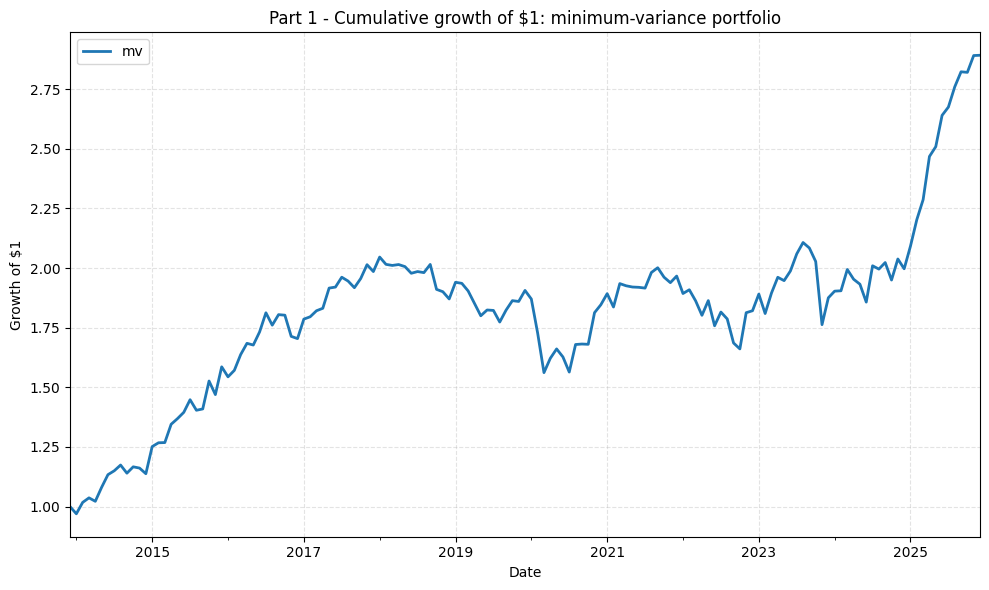

In [10]:
plot_cumulative(monthly, ["mv"], FIGURES / "part1_cumulative_mv.png",
                "Part 1 - Cumulative growth of $1: minimum-variance portfolio")

## 5. Part 2 - Value-Weighted benchmark (P_vw)

**What we do:** strict Section 2.3 cap-weighted index. Each month, weights are the previous-month market caps normalised to 1; the current-month returns are weighted by those previous-month weights.

**Why it matters:** the VW index is the natural passive benchmark. It tells us what a market-cap investor would have earned with no optimisation, and serves as the reference for tracking error in Parts 3 and 4.

**Files saved here:** `part2_returns_vw.csv`, `part2_performance_vw.csv`, `part2_cumulative_vw.png`, `part2_cumulative_mv_vs_vw.png`.

In [11]:
vw_returns = monthly[["vw"]].copy()
vw_returns.to_csv(TABLES / "part2_returns_vw.csv", index_label="date")

# Part 2 perf table mirrors the existing format: vw and mv side-by-side
part2_perf = summary_stats(monthly[["vw", "mv"]], rf=rf_monthly, benchmark="vw")
part2_perf.to_csv(TABLES / "part2_performance_vw.csv", index=False)

print("Part 2 - performance summary:")
display(part2_perf)
print("\nVW monthly returns (head):")
display(vw_returns.head())

Part 2 - performance summary:


,portfolio,annualized_return,annualized_volatility,annualized_rf,return_to_volatility,excess_sharpe_ratio,tracking_error_vs_vw,minimum_monthly_return,maximum_monthly_return,cumulative_return,terminal_growth
0,vw,0.0737,0.1289,0.0175,0.5718,0.4362,NaN,-0.1076,0.1308,1.1865,2.1865
1,mv,0.0966,0.1242,0.0175,0.7771,0.6365,0.1045,-0.1306,0.0999,1.8923,2.8923



VW monthly returns (head):


,vw
2014-01-31,-0.0435
2014-02-28,0.0192
2014-03-31,0.0027
2014-04-30,-0.0069
2014-05-30,0.0303


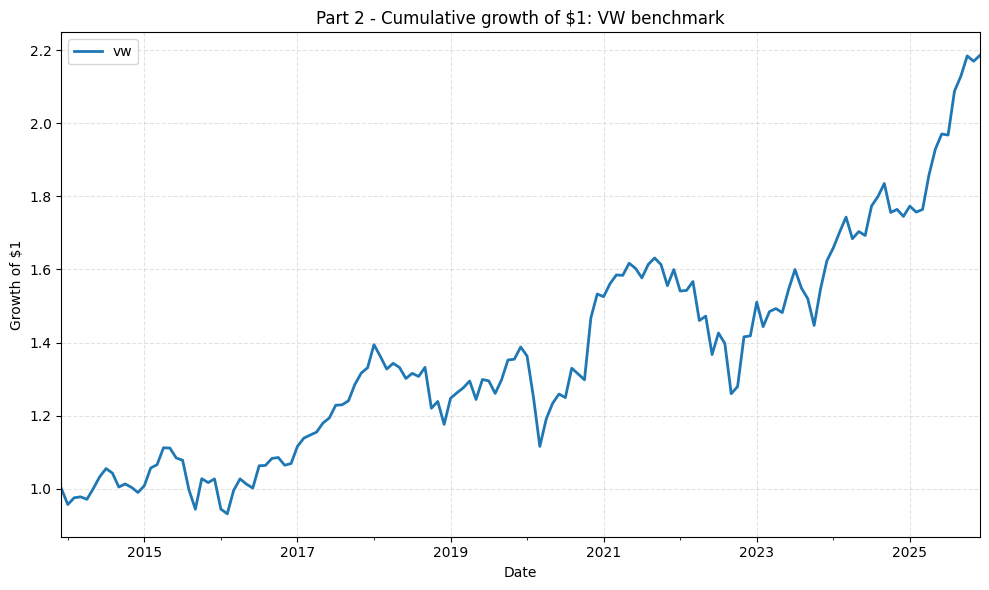

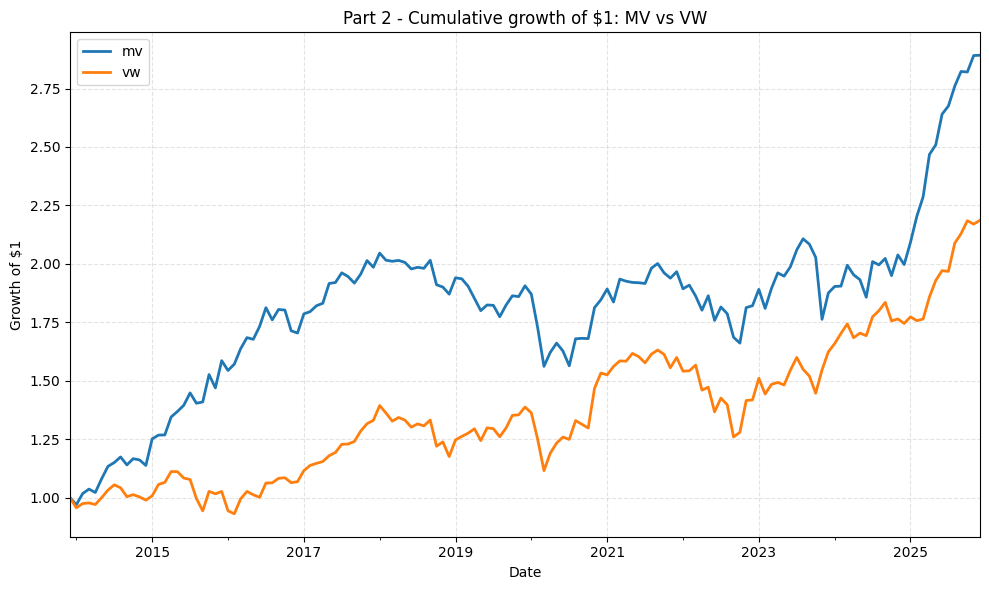

In [12]:
plot_cumulative(monthly, ["vw"], FIGURES / "part2_cumulative_vw.png",
                "Part 2 - Cumulative growth of $1: VW benchmark")
plot_cumulative(monthly, ["mv", "vw"], FIGURES / "part2_cumulative_mv_vs_vw.png",
                "Part 2 - Cumulative growth of $1: MV vs VW")

## 6. Part 3 - 50% carbon-footprint reduction

**What we do:** we add a carbon-footprint constraint equal to 50% of the reference portfolio's carbon footprint.

- \(P_{mv,50}\): minimum-variance portfolio with carbon footprint capped at 50% of \(P_{mv}\).
- \(P_{vw,50}\): tracking-error minimisation versus \(P_{vw}\), with carbon footprint capped at 50% of \(P_{vw}\).

**Why it matters:** this section checks whether a significant carbon reduction can be achieved without creating a large financial cost. For the minimum-variance strategy, the cost is measured through volatility and Sharpe ratio. For the benchmark-relative strategy, the key measure is tracking error.

Section 3.1 also reports the main WACI and carbon-footprint contributors of the value-weighted benchmark, which helps identify which firms drive the portfolio's climate exposure.

Section 3.1 - annual carbon metrics MV vs VW:


,year,implementation_year,portfolio,n_assets,waci_tco2e_per_musd_revenue,carbon_footprint_tco2e_per_musd_invested,carbon_limit,optimization_success,optimization_message
0,2013,2014,vw,258,191.5143,227.9316,227.9316,True,benchmark (drift)
1,2013,2014,mv,258,"2,031.1244",736.3526,NaN,True,Optimization terminated successfully
5,2014,2015,vw,268,172.7446,205.4383,205.4383,True,benchmark (drift)
6,2014,2015,mv,268,919.9366,624.1732,NaN,True,Optimization terminated successfully
10,2015,2016,vw,289,339.9492,213.6181,213.6181,True,benchmark (drift)
11,2015,2016,mv,289,"2,445.8524",429.1745,NaN,True,Optimization terminated successfully
15,2016,2017,vw,314,443.4581,265.1164,265.1164,True,benchmark (drift)
16,2016,2017,mv,314,"4,070.1210",501.5896,NaN,True,Optimization terminated successfully
20,2017,2018,vw,341,517.2877,232.7717,232.7717,True,benchmark (drift)
21,2017,2018,mv,341,"1,130.9062",493.4001,NaN,True,Optimization terminated successfully



Top-10 WACI contributors (head):


,year,rank,ISIN,name,country,ci_tco2e_per_musd_revenue,vw_weight,vw_waci_contribution
0,2013,1,HK0006000050,POWER ASSETS HOLDINGS,HK,"6,673.7625",0.0061,40.9055
1,2013,2,HK0002007356,CLP HOLDINGS,HK,"2,829.3242",0.0071,20.2068
2,2013,3,AU0000224040,WOODSIDE ENERGY GROUP,AU,"1,442.9466",0.0102,14.6566
3,2013,4,AU000000BHP4,BHP GROUP,AU,329.4661,0.0421,13.8757
4,2013,5,HK0019000162,SWIRE PACIFIC 'A',HK,"2,844.0929",0.0039,11.0342



Top-10 CF contributors (head):


,year,rank,ISIN,name,country,cf_per_weight_tco2e_per_musd_invested,vw_weight,vw_cf_contribution
0,2013,1,JP3526600006,CHUBU ELEC.POWER,JP,"5,953.1532",0.0031,18.3083
1,2013,2,JP3551200003,ELEC.POWER DEV.,JP,"14,430.5033",0.0012,17.9857
2,2013,3,JP3228600007,KANSAI ELECTRIC PWR.,JP,"6,032.3787",0.0029,17.2010
3,2013,4,JP3522200009,CHUGOKU ELEC.POWER,JP,"8,642.9132",0.0016,13.6564
4,2013,5,JP3605400005,TOHOKU ELECTRIC PWR.,JP,"10,316.5679",0.0013,13.5795


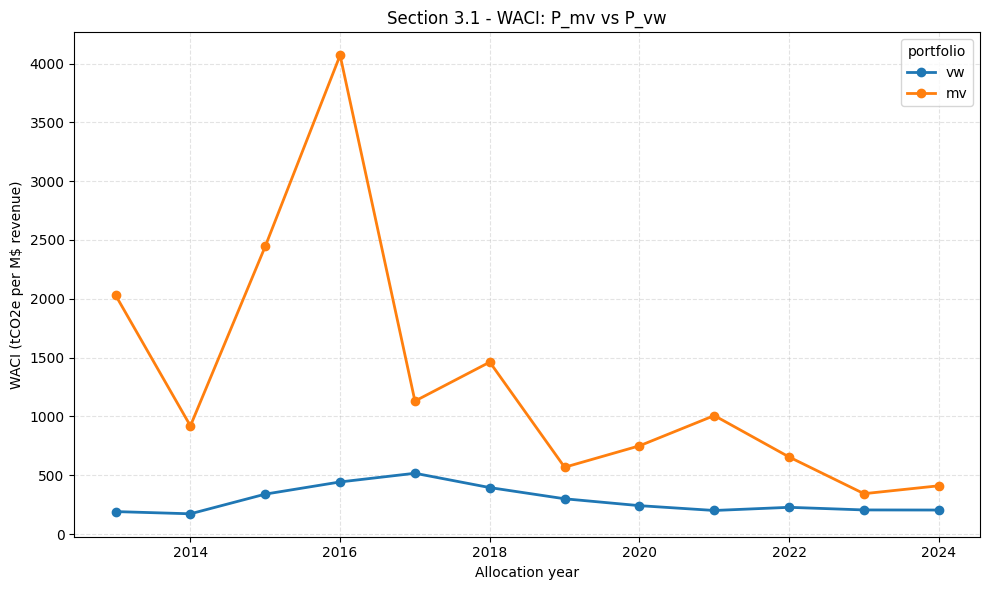

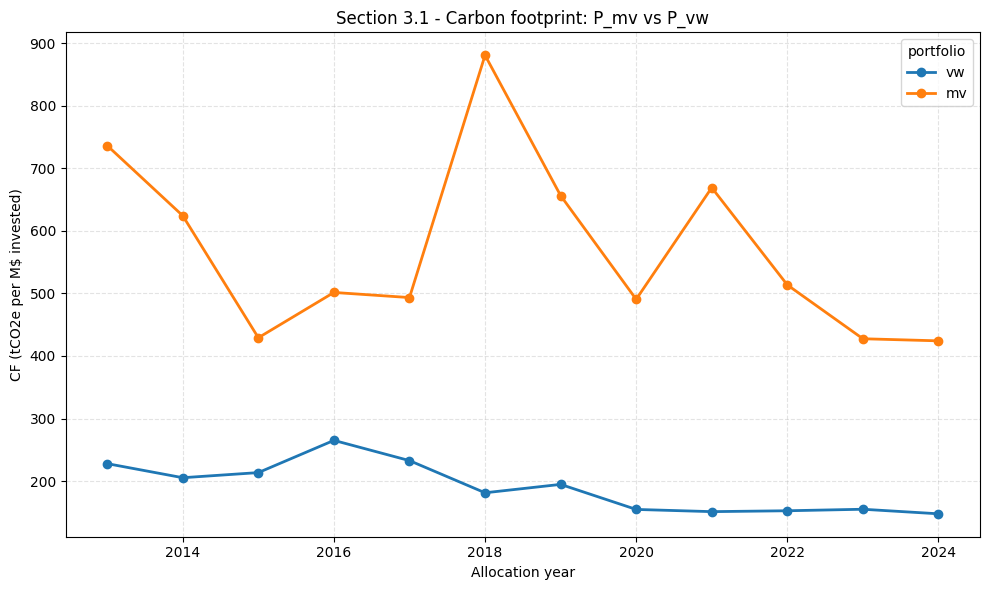

In [13]:
# Section 3.1 - carbon metrics MV vs VW + top10 contributors
metrics_3_1 = annual[annual["portfolio"].isin(["vw_drift", "mv"])].copy()
metrics_3_1["portfolio"] = metrics_3_1["portfolio"].replace({"vw_drift": "vw"})
metrics_3_1.to_csv(TABLES / "part3_carbon_metrics_mv_vw.csv", index=False)
waci_top.to_csv(TABLES / "part3_top10_waci_contributors.csv", index=False)
cf_top.to_csv(TABLES / "part3_top10_cf_contributors.csv", index=False)

print("Section 3.1 - annual carbon metrics MV vs VW:")
display(metrics_3_1.head(12))
print("\nTop-10 WACI contributors (head):")
display(waci_top.head())
print("\nTop-10 CF contributors (head):")
display(cf_top.head())

plot_annual(metrics_3_1, "waci_tco2e_per_musd_revenue", ["vw", "mv"],
            FIGURES / "part3_waci_mv_vs_vw.png",
            "Section 3.1 - WACI: P_mv vs P_vw",
            "WACI (tCO2e per M$ revenue)")
plot_annual(metrics_3_1, "carbon_footprint_tco2e_per_musd_invested", ["vw", "mv"],
            FIGURES / "part3_carbon_footprint_mv_vs_vw.png",
            "Section 3.1 - Carbon footprint: P_mv vs P_vw",
            "CF (tCO2e per M$ invested)")

### How to read the carbon contributor tables

The top contributors are not necessarily the firms with the highest emissions in absolute terms. A firm can appear as a large contributor because it has a high portfolio weight, a high carbon intensity, or both.

For WACI, the contribution depends on the firm's carbon intensity relative to revenues. For carbon footprint, the contribution depends on emissions relative to market capitalisation. This is why the two rankings can differ.

These tables are useful because they show which firms drive the portfolio’s climate exposure before applying the carbon constraints.

Section 3.2 - MV vs MV(-50%) summary:


,portfolio,annualized_return,annualized_volatility,annualized_rf,return_to_volatility,excess_sharpe_ratio,tracking_error_vs_vw,minimum_monthly_return,maximum_monthly_return,cumulative_return,terminal_growth
1,mv,0.0966,0.1242,0.0175,0.7771,0.6365,0.1045,-0.1306,0.0999,1.8923,2.8923
2,mv_50,0.0938,0.1316,0.0175,0.7129,0.5801,0.1106,-0.1595,0.1008,1.7663,2.7663


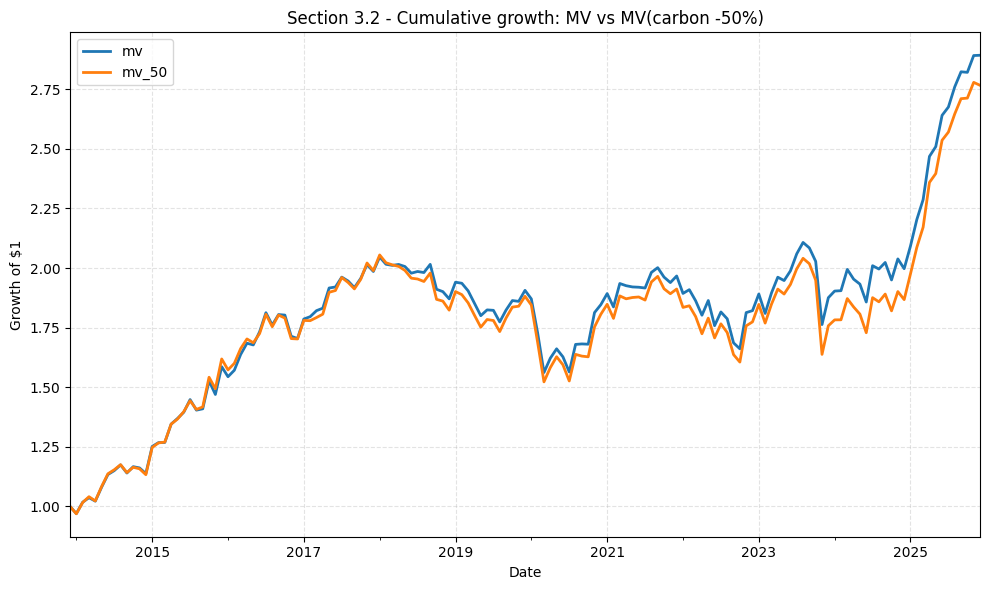

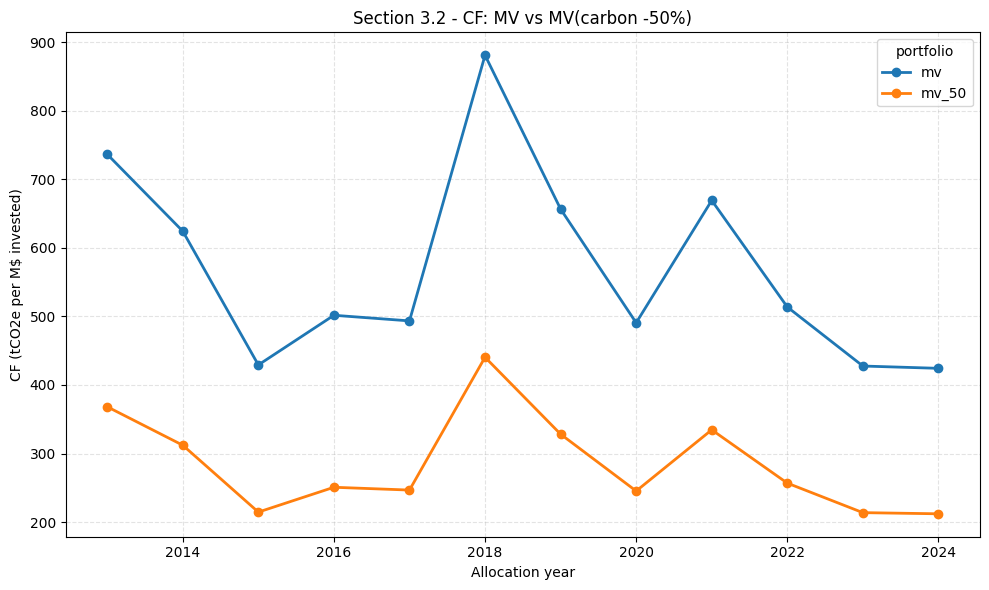

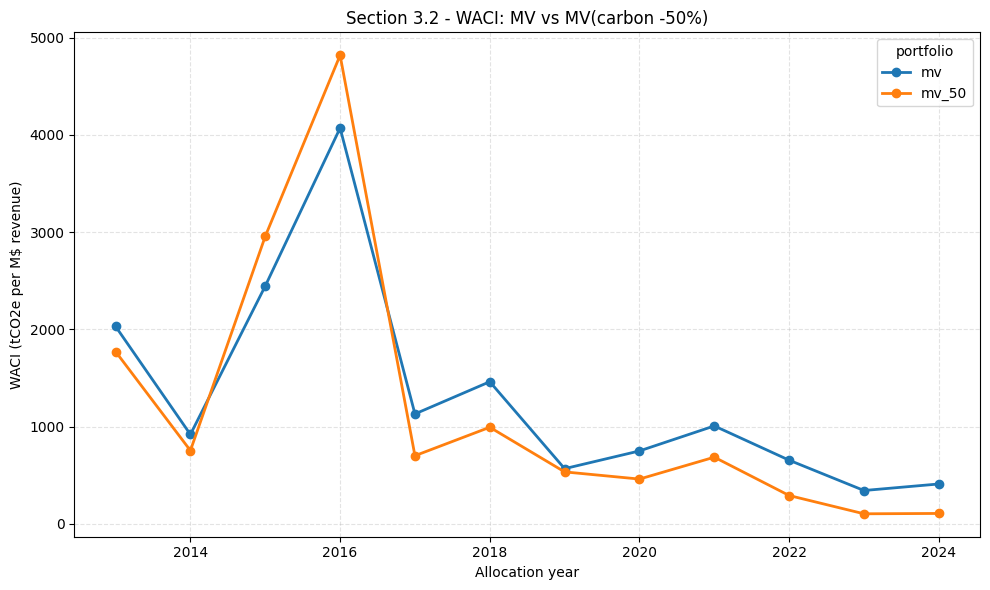

In [14]:
# Section 3.2 - MV vs MV(-50%)
monthly[["mv", "mv_50"]].to_csv(TABLES / "part3_returns_mv_carbon50.csv", index_label="date")
summary_mv = summary_stats(monthly[["vw", "mv", "mv_50"]], rf=rf_monthly, benchmark="vw")
summary_mv = summary_mv[summary_mv["portfolio"].isin(["mv", "mv_50"])]
summary_mv.to_csv(TABLES / "part3_summary_mv_vs_mv_carbon50.csv", index=False)
weights[weights["portfolio"].isin(["mv", "mv_50"])].to_csv(
    TABLES / "part3_weights_mv_carbon50.csv", index=False)
slack_table[slack_table["portfolio"] == "mv_50"].to_csv(
    TABLES / "part3_constraint_slack_mv_carbon50.csv", index=False)

print("Section 3.2 - MV vs MV(-50%) summary:")
display(summary_mv)

plot_cumulative(monthly, ["mv", "mv_50"],
                FIGURES / "part3_cumulative_mv_vs_mv_carbon50.png",
                "Section 3.2 - Cumulative growth: MV vs MV(carbon -50%)")
plot_annual(annual, "carbon_footprint_tco2e_per_musd_invested", ["mv", "mv_50"],
            FIGURES / "part3_cf_mv_vs_mv_carbon50.png",
            "Section 3.2 - CF: MV vs MV(carbon -50%)",
            "CF (tCO2e per M$ invested)")
plot_annual(annual, "waci_tco2e_per_musd_revenue", ["mv", "mv_50"],
            FIGURES / "part3_waci_mv_vs_mv_carbon50.png",
            "Section 3.2 - WACI: MV vs MV(carbon -50%)",
            "WACI (tCO2e per M$ revenue)")

Section 3.3 - VW vs VW(-50%) summary:


,portfolio,annualized_return,annualized_volatility,annualized_rf,return_to_volatility,excess_sharpe_ratio,tracking_error_vs_vw,minimum_monthly_return,maximum_monthly_return,cumulative_return,terminal_growth
0,vw,0.0737,0.1289,0.0175,0.5718,0.4362,NaN,-0.1076,0.1308,1.1865,2.1865
1,vw_50,0.0904,0.1395,0.0175,0.6476,0.5223,0.0314,-0.1510,0.1283,1.6214,2.6214


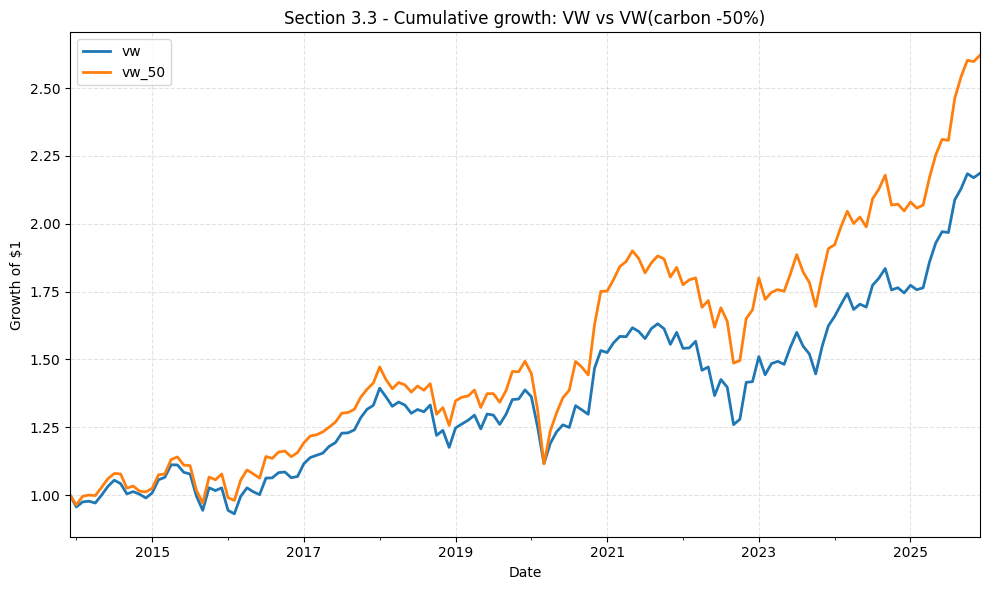

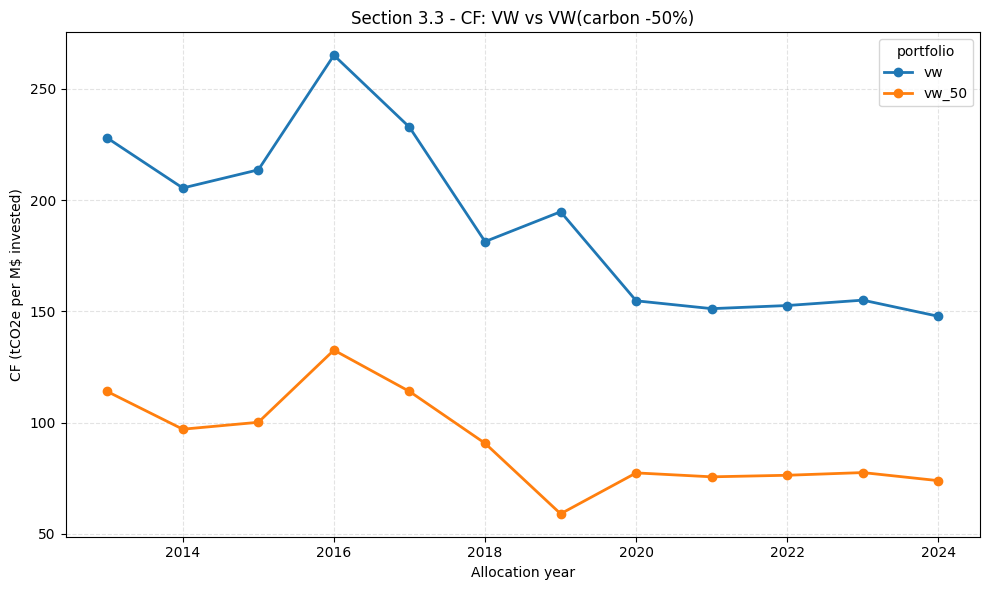

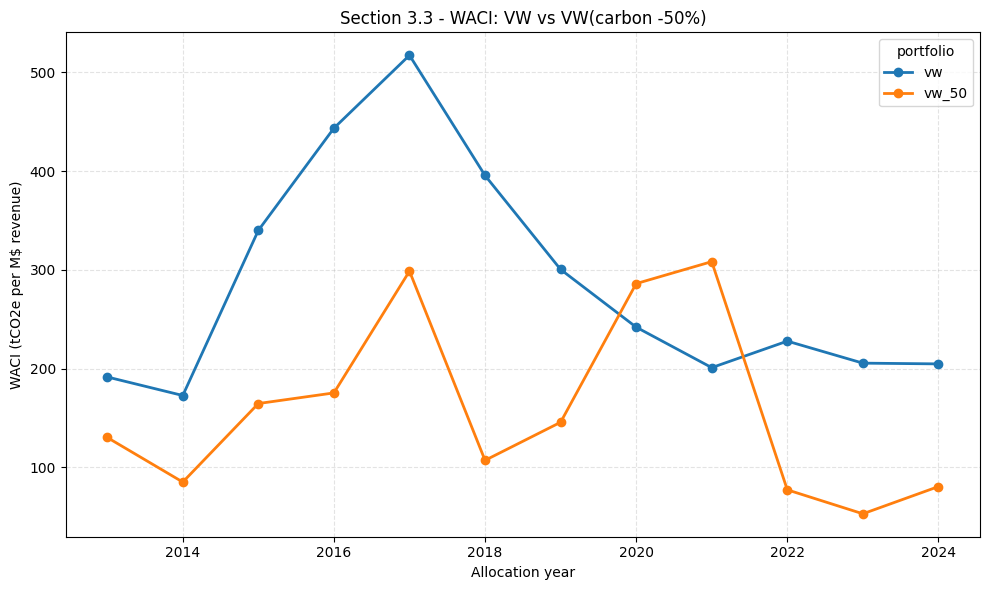

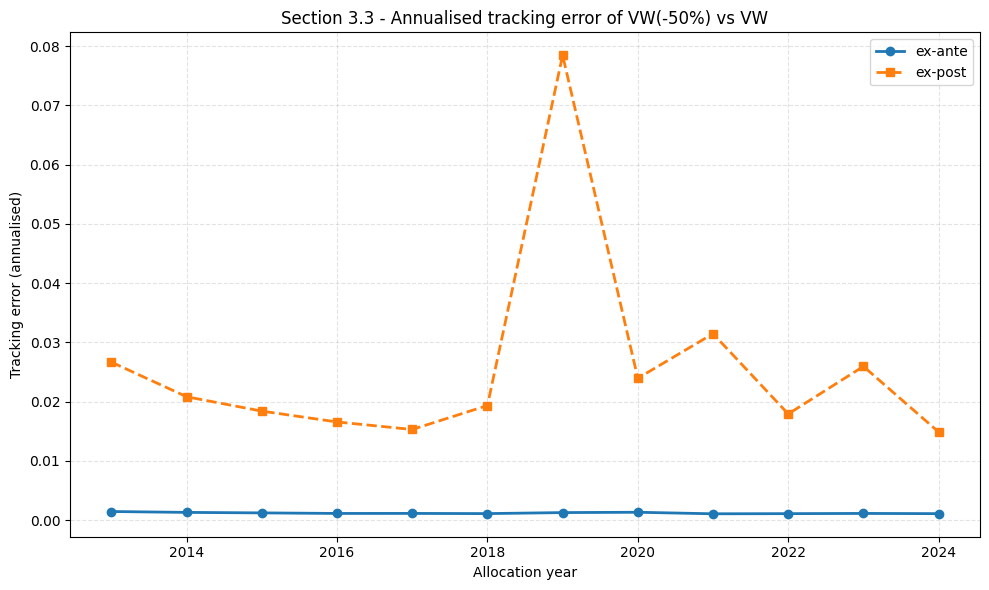

In [15]:
# Section 3.3 - VW vs VW(-50%)
monthly[["vw", "vw_50"]].to_csv(TABLES / "part3_returns_vw_carbon50.csv", index_label="date")
summary_vw = summary_stats(monthly[["vw", "vw_50"]], rf=rf_monthly, benchmark="vw")
summary_vw.to_csv(TABLES / "part3_summary_vw_vs_vw_carbon50.csv", index=False)

weights_vw_view = weights.copy()
weights_vw_view.loc[weights_vw_view["portfolio"] == "vw_drift", "portfolio"] = "vw"
weights_vw_view[weights_vw_view["portfolio"].isin(["vw", "vw_50"])].to_csv(
    TABLES / "part3_weights_vw_carbon50.csv", index=False)
te_table[te_table["portfolio"] == "vw_50"].to_csv(
    TABLES / "part3_tracking_error_vw_carbon50.csv", index=False)
slack_table[slack_table["portfolio"] == "vw_50"].to_csv(
    TABLES / "part3_constraint_slack_vw_carbon50.csv", index=False)

print("Section 3.3 - VW vs VW(-50%) summary:")
display(summary_vw)

plot_cumulative(monthly, ["vw", "vw_50"],
                FIGURES / "part3_cumulative_vw_vs_vw_carbon50.png",
                "Section 3.3 - Cumulative growth: VW vs VW(carbon -50%)")

annual_vw_view = annual.copy()
annual_vw_view["portfolio"] = annual_vw_view["portfolio"].replace({"vw_drift": "vw"})
plot_annual(annual_vw_view, "carbon_footprint_tco2e_per_musd_invested", ["vw", "vw_50"],
            FIGURES / "part3_cf_vw_vs_vw_carbon50.png",
            "Section 3.3 - CF: VW vs VW(carbon -50%)",
            "CF (tCO2e per M$ invested)")
plot_annual(annual_vw_view, "waci_tco2e_per_musd_revenue", ["vw", "vw_50"],
            FIGURES / "part3_waci_vw_vs_vw_carbon50.png",
            "Section 3.3 - WACI: VW vs VW(carbon -50%)",
            "WACI (tCO2e per M$ revenue)")

# ex-ante / ex-post TE plot
te_vw50 = te_table[te_table["portfolio"] == "vw_50"]
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(te_vw50["year"], te_vw50["ex_ante_tracking_error_annual"], marker="o", linewidth=2, label="ex-ante")
ax.plot(te_vw50["year"], te_vw50["ex_post_tracking_error_annual"], marker="s", linewidth=2, linestyle="--", label="ex-post")
ax.set_title("Section 3.3 - Annualised tracking error of VW(-50%) vs VW")
ax.set_xlabel("Allocation year"); ax.set_ylabel("Tracking error (annualised)")
ax.grid(True, linestyle="--", alpha=0.35); ax.legend()
fig.tight_layout(); fig.savefig(FIGURES / "part3_tracking_error_vw_carbon50.png", dpi=160)
plt.show()

## 7. Part 4 - Net-Zero trajectory \(P_{vw,NZ}\)

**What we do:** the carbon cap declines by 10% per year from a 2013 anchor equal to the carbon footprint of the value-weighted benchmark:

$$
C_Y = (1 - \theta)^{Y - 2013 + 1} \cdot CF(P_{vw,2013}), 
\qquad \theta = 10\%.
$$

For each year, the portfolio minimises tracking error versus \(P_{vw}\), subject to the Net-Zero carbon cap:

$$
CF(w_Y) \leq C_Y.
$$

**Why it matters:** this is different from a one-time 50% reduction. The constraint becomes progressively tighter over time, which gives a more realistic view of a long-term decarbonisation policy.

The question is whether the portfolio can follow this declining carbon path while remaining close to the benchmark. If tracking error stays low, the Net-Zero strategy is easier to implement for a benchmark-oriented investor. If tracking error increases strongly, the climate objective becomes more costly in active-risk terms.

In [16]:
monthly[["vw", "vw_nz"]].to_csv(TABLES / "part4_returns_vw_netzero.csv", index_label="date")
joint_monthly = monthly[["vw", "vw_50", "vw_nz"]].copy()
summary_part4 = summary_stats(joint_monthly, rf=rf_monthly, benchmark="vw")
summary_part4.to_csv(TABLES / "part4_summary_vw_vs_carbon50_vs_netzero.csv", index=False)
weights[weights["portfolio"] == "vw_nz"].to_csv(
    TABLES / "part4_weights_vw_netzero.csv", index=False)
path_table.to_csv(TABLES / "part4_netzero_target_vs_realized_cf.csv", index=False)
te_table[te_table["portfolio"] == "vw_nz"].to_csv(
    TABLES / "part4_tracking_error_vw_netzero.csv", index=False)
slack_table[slack_table["portfolio"] == "vw_nz"].to_csv(
    TABLES / "part4_constraint_slack_vw_netzero.csv", index=False)

print("Part 4 - VW vs VW(-50%) vs VW(NZ) summary:")
display(summary_part4)
print("\nPart 4 - net-zero cap path vs realised CF:")
display(path_table)

Part 4 - VW vs VW(-50%) vs VW(NZ) summary:


,portfolio,annualized_return,annualized_volatility,annualized_rf,return_to_volatility,excess_sharpe_ratio,tracking_error_vs_vw,minimum_monthly_return,maximum_monthly_return,cumulative_return,terminal_growth
0,vw,0.0737,0.1289,0.0175,0.5718,0.4362,NaN,-0.1076,0.1308,1.1865,2.1865
1,vw_50,0.0904,0.1395,0.0175,0.6476,0.5223,0.0314,-0.1510,0.1283,1.6214,2.6214
2,vw_nz,0.0890,0.1400,0.0175,0.6355,0.5107,0.0308,-0.1535,0.1285,1.5763,2.5763



Part 4 - net-zero cap path vs realised CF:


,year,implementation_year,anchor_cf_vw_2013,theta,carbon_limit_nz,carbon_footprint_vw,carbon_footprint_vw_nz,slack,feasible_within_1e-6,optimizer_success
0,2013,2014,227.9316,0.1000,205.1384,227.9316,205.1384,-0.0000,True,True
1,2014,2015,227.9316,0.1000,184.6246,205.4383,176.2483,8.3763,True,True
2,2015,2016,227.9316,0.1000,166.1621,213.6181,132.7831,33.3790,True,True
3,2016,2017,227.9316,0.1000,149.5459,265.1164,149.5459,0.0000,True,True
4,2017,2018,227.9316,0.1000,134.5913,232.7717,134.5913,0.0000,True,True
5,2018,2019,227.9316,0.1000,121.1322,181.3526,121.1322,0.0000,True,True
6,2019,2020,227.9316,0.1000,109.0190,194.7648,76.0181,33.0009,True,True
7,2020,2021,227.9316,0.1000,98.1171,154.7323,98.1171,-0.0000,True,True
8,2021,2022,227.9316,0.1000,88.3054,151.2048,88.3054,0.0000,True,True
9,2022,2023,227.9316,0.1000,79.4748,152.6107,79.4233,0.0515,True,True


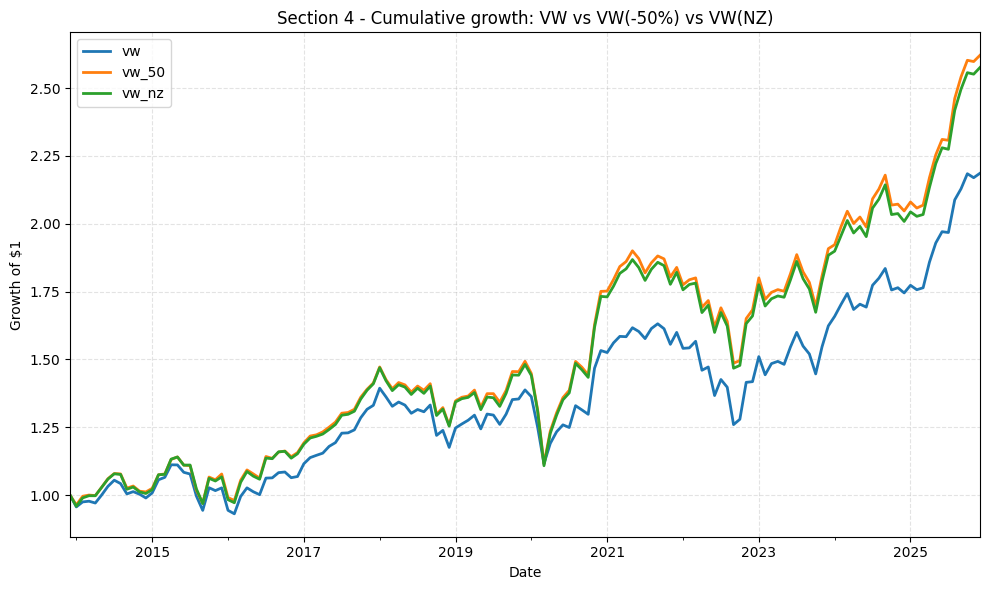

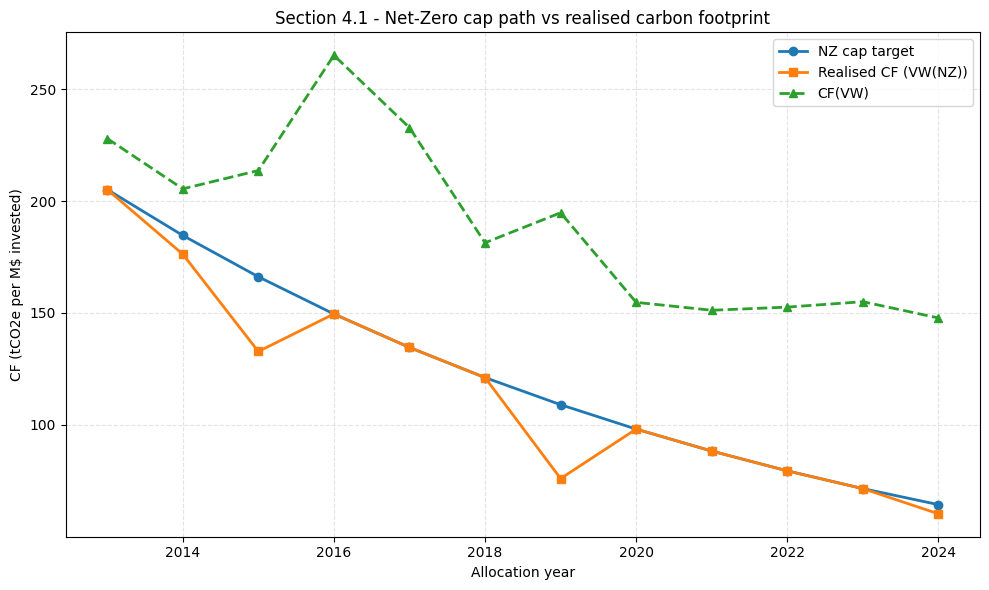

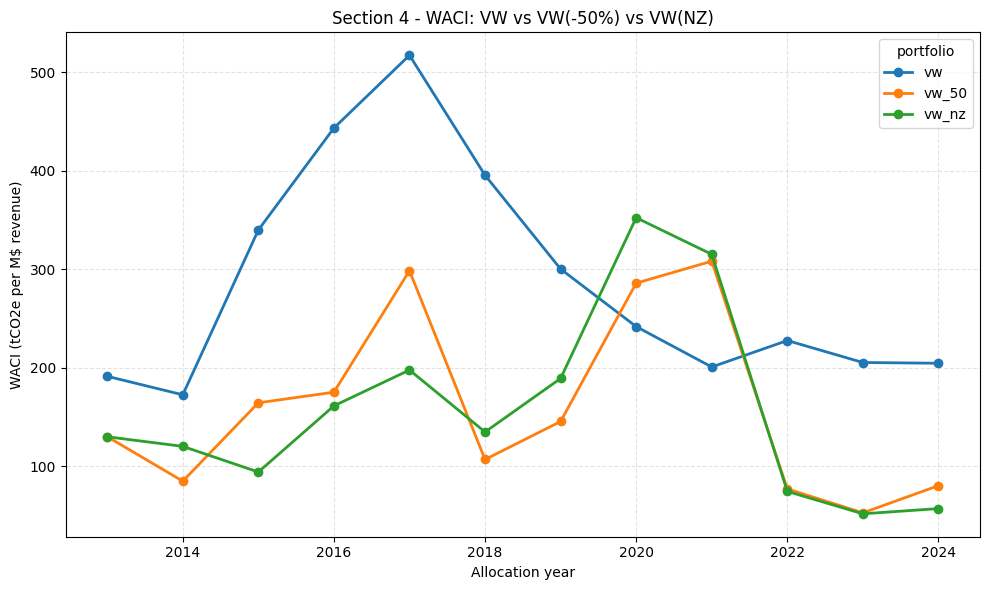

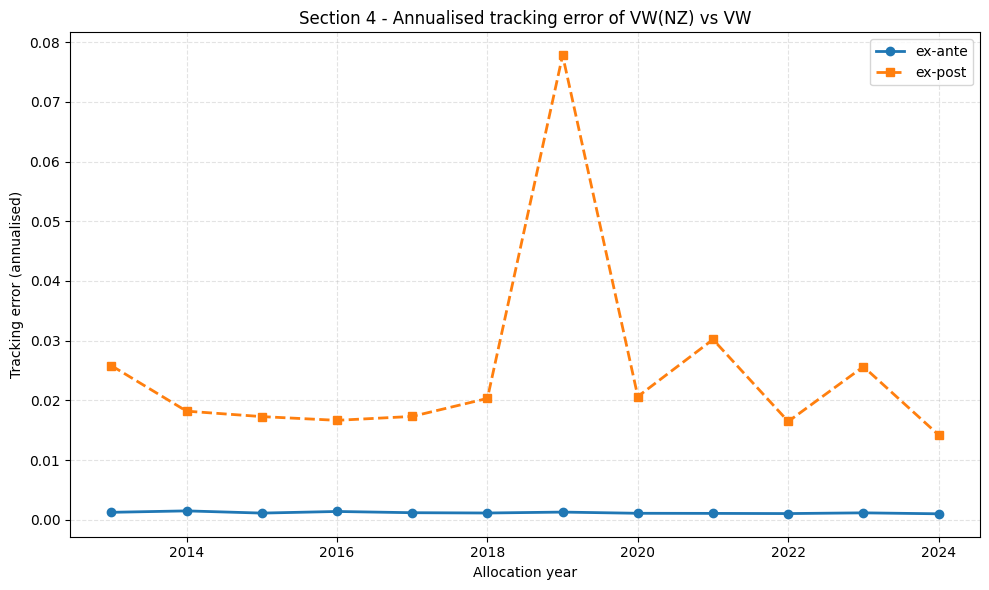

In [17]:
# Part 4 figures
plot_cumulative(joint_monthly, ["vw", "vw_50", "vw_nz"],
                FIGURES / "part4_cumulative_vw_vs_carbon50_vs_netzero.png",
                "Section 4 - Cumulative growth: VW vs VW(-50%) vs VW(NZ)")

# CF target vs realised
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(path_table["year"], path_table["carbon_limit_nz"], marker="o", linewidth=2, label="NZ cap target")
ax.plot(path_table["year"], path_table["carbon_footprint_vw_nz"], marker="s", linewidth=2, label="Realised CF (VW(NZ))")
ax.plot(path_table["year"], path_table["carbon_footprint_vw"], marker="^", linewidth=2, linestyle="--", label="CF(VW)")
ax.set_title("Section 4.1 - Net-Zero cap path vs realised carbon footprint")
ax.set_xlabel("Allocation year"); ax.set_ylabel("CF (tCO2e per M$ invested)")
ax.grid(True, linestyle="--", alpha=0.35); ax.legend()
fig.tight_layout(); fig.savefig(FIGURES / "part4_cf_target_vs_realized.png", dpi=160)
plt.show()

# joint WACI: VW / VW(-50%) / VW(NZ)
annual_view = annual.copy()
annual_view["portfolio"] = annual_view["portfolio"].replace({"vw_drift": "vw"})
waci_panel = annual_view[annual_view["portfolio"].isin(["vw", "vw_50", "vw_nz"])]
plot_annual(waci_panel, "waci_tco2e_per_musd_revenue", ["vw", "vw_50", "vw_nz"],
            FIGURES / "part4_waci_vw_vs_carbon50_vs_netzero.png",
            "Section 4 - WACI: VW vs VW(-50%) vs VW(NZ)",
            "WACI (tCO2e per M$ revenue)")

# TE of VW(NZ)
te_nz = te_table[te_table["portfolio"] == "vw_nz"]
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(te_nz["year"], te_nz["ex_ante_tracking_error_annual"], marker="o", linewidth=2, label="ex-ante")
ax.plot(te_nz["year"], te_nz["ex_post_tracking_error_annual"], marker="s", linewidth=2, linestyle="--", label="ex-post")
ax.set_title("Section 4 - Annualised tracking error of VW(NZ) vs VW")
ax.set_xlabel("Allocation year"); ax.set_ylabel("Tracking error (annualised)")
ax.grid(True, linestyle="--", alpha=0.35); ax.legend()
fig.tight_layout(); fig.savefig(FIGURES / "part4_tracking_error_vw_netzero.png", dpi=160)
plt.show()

## 8. Final performance summary

### Sharpe ratio (aligned RF)

Every Sharpe ratio in this notebook is built from annualized arithmetic monthly averages, with the risk-free rate aligned to the same calendar month as the portfolio returns:

1. take the monthly RF series,
2. align it to portfolio returns by calendar month, so trading month-ends and calendar month-ends still match,
3. annualise the monthly portfolio mean, RF mean, and excess-return mean,
4. Sharpe = annualized mean excess return / annualized volatility.

The validation cell below shows the date range, number of observations, RF matches, and aligned RF for every portfolio. This makes the alignment fully verifiable.

In [18]:
# Validation cell: shows that RF is aligned per portfolio by calendar month
rf_by_month = rf_monthly.copy()
rf_by_month.index = rf_by_month.index.to_period("M")
validation_rows = []
for col in monthly.columns:
    r = monthly[col].dropna()
    if not len(r):
        continue
    rf_aligned = rf_by_month.reindex(r.index.to_period("M"))
    valid_rf = rf_aligned.notna().to_numpy()
    ann_ret = float(r.mean() * 12.0)
    ann_vol = r.std(ddof=0) * np.sqrt(12.0)
    ann_rf = float(rf_aligned.dropna().mean() * 12.0) if valid_rf.any() else 0.0
    if ann_vol > 0 and valid_rf.any():
        ann_excess = float((r.to_numpy()[valid_rf] - rf_aligned.to_numpy()[valid_rf]).mean() * 12.0)
        sharpe = ann_excess / ann_vol
    elif ann_vol > 0:
        sharpe = ann_ret / ann_vol
    else:
        sharpe = np.nan
    validation_rows.append({
        "portfolio": col,
        "start_date": str(r.index.min().date()),
        "end_date": str(r.index.max().date()),
        "n_obs": int(len(r)),
        "n_rf_matches": int(valid_rf.sum()),
        "annualized_return": ann_ret,
        "annualized_volatility": ann_vol,
        "aligned_annualized_rf": ann_rf,
        "sharpe_ratio": sharpe,
    })
validation_df = pd.DataFrame(validation_rows)
print("Validation - RF aligned per portfolio (portfolio evaluation window only):")
display(validation_df)

Validation - RF aligned per portfolio (portfolio evaluation window only):


,portfolio,start_date,end_date,n_obs,n_rf_matches,annualized_return,annualized_volatility,aligned_annualized_rf,sharpe_ratio
0,vw,2014-01-31,2025-12-31,144,144,0.0737,0.1289,0.0175,0.4362
1,vw_drift,2014-01-31,2025-12-31,144,144,0.0740,0.1317,0.0175,0.4287
2,mv,2014-01-31,2025-12-31,144,144,0.0966,0.1242,0.0175,0.6365
3,mv_50,2014-01-31,2025-12-31,144,144,0.0938,0.1316,0.0175,0.5801
4,vw_50,2014-01-31,2025-12-31,144,144,0.0904,0.1395,0.0175,0.5223
5,vw_nz,2014-01-31,2025-12-31,144,144,0.0890,0.1400,0.0175,0.5107


### Risk-free rate alignment

This validation checks that the risk-free rate is correctly aligned with the monthly returns of each portfolio before computing Sharpe ratios.

The Sharpe ratio is based on excess returns:

$$
R_{p,t} - R_{f,t}
$$

so the risk-free rate must correspond to the same month as the portfolio return. If the dates were not aligned correctly, the excess returns and Sharpe ratios could be biased.

In the notebook, the risk-free rate is matched by calendar month for each portfolio. Then the annualised Sharpe ratio is computed as:

$$
Sharpe = \frac{E[R_p - R_f]}{\sigma_p}
$$

This step is useful because the portfolios do not necessarily have exactly the same return observations after cleaning and implementation. The validation confirms that the performance comparison is done using a consistent risk-free rate convention.

In [19]:
# Validation checks for cleaning update and unchanged portfolio conventions.
print("Cleaning / portfolio validation checks")
print("Allocation years:", int(annual["year"].min()), "to", int(annual["year"].max()))
print("Implementation years:", int(annual["implementation_year"].min()), "to", int(annual["implementation_year"].max()))
print("Portfolio labels:", list(monthly.columns))
print("Sharpe definition: excess_sharpe_ratio = annualized monthly excess return / annualized monthly volatility")
print("Benchmark logic: VW is monthly cap-weighted; VW_50 and VW_NZ optimize tracking error against annual w_vw inside build_year_inputs(year).")
terminal_values = (1.0 + monthly[["vw", "mv", "mv_50", "vw_50", "vw_nz"]]).prod()
print("Terminal cumulative values by portfolio:")
display(terminal_values.rename("terminal_growth").to_frame())
print("Note: any material terminal-growth change should come only from the raw price cleaning/delisting treatment above, not from optimization logic.")


Cleaning / portfolio validation checks
Allocation years: 2013 to 2024
Implementation years: 2014 to 2025
Portfolio labels: ['vw', 'vw_drift', 'mv', 'mv_50', 'vw_50', 'vw_nz']
Sharpe definition: excess_sharpe_ratio = annualized monthly excess return / annualized monthly volatility
Benchmark logic: VW is monthly cap-weighted; VW_50 and VW_NZ optimize tracking error against annual w_vw inside build_year_inputs(year).
Terminal cumulative values by portfolio:


,terminal_growth
vw,2.1865
mv,2.8923
mv_50,2.7663
vw_50,2.6214
vw_nz,2.5763


Note: any material terminal-growth change should come only from the raw price cleaning/delisting treatment above, not from optimization logic.


In [20]:
# Final headline summary across all five portfolios
final_summary = summary_stats(monthly[["vw", "mv", "mv_50", "vw_50", "vw_nz"]],
                              rf=rf_monthly, benchmark="vw")
final_summary.to_csv(TABLES / "final_performance_summary.csv", index=False)
print("Final performance summary (saved to outputs/tables/final_performance_summary.csv):")
display(final_summary)

portfolio_file_index = pd.DataFrame([
    {"portfolio": "vw", "description": "strict monthly-rebalanced value-weighted benchmark", "main_return_file": "part2_returns_vw.csv"},
    {"portfolio": "vw_drift", "description": "annual value-weighted allocation with intra-year drift", "main_return_file": "all_portfolio_monthly_returns.csv"},
    {"portfolio": "mv", "description": "long-only minimum-variance portfolio", "main_return_file": "part1_mv_returns.csv"},
    {"portfolio": "mv_50", "description": "minimum variance with 50% carbon-footprint cap", "main_return_file": "part3_returns_mv_carbon50.csv"},
    {"portfolio": "vw_50", "description": "tracking-error portfolio with 50% carbon-footprint cap", "main_return_file": "part3_returns_vw_carbon50.csv"},
    {"portfolio": "vw_nz", "description": "tracking-error portfolio on the Net-Zero carbon path", "main_return_file": "part4_returns_vw_netzero.csv"},
])
portfolio_file_index.to_csv(TABLES / "portfolio_file_index.csv", index=False)

output_files = file_inventory(OUTPUTS)
output_files.to_csv(TABLES / "output_file_inventory.csv", index=False)
print("Portfolio construction index:")
display(portfolio_file_index)
print("Output files generated by this notebook:")
display(output_files)

Final performance summary (saved to outputs/tables/final_performance_summary.csv):


,portfolio,annualized_return,annualized_volatility,annualized_rf,return_to_volatility,excess_sharpe_ratio,tracking_error_vs_vw,minimum_monthly_return,maximum_monthly_return,cumulative_return,terminal_growth
0,vw,0.0737,0.1289,0.0175,0.5718,0.4362,NaN,-0.1076,0.1308,1.1865,2.1865
1,mv,0.0966,0.1242,0.0175,0.7771,0.6365,0.1045,-0.1306,0.0999,1.8923,2.8923
2,mv_50,0.0938,0.1316,0.0175,0.7129,0.5801,0.1106,-0.1595,0.1008,1.7663,2.7663
3,vw_50,0.0904,0.1395,0.0175,0.6476,0.5223,0.0314,-0.1510,0.1283,1.6214,2.6214
4,vw_nz,0.0890,0.1400,0.0175,0.6355,0.5107,0.0308,-0.1535,0.1285,1.5763,2.5763


Portfolio construction index:


,portfolio,description,main_return_file
0,vw,strict monthly-rebalanced value-weighted bench...,part2_returns_vw.csv
1,vw_drift,annual value-weighted allocation with intra-ye...,all_portfolio_monthly_returns.csv
2,mv,long-only minimum-variance portfolio,part1_mv_returns.csv
3,mv_50,minimum variance with 50% carbon-footprint cap,part3_returns_mv_carbon50.csv
4,vw_50,tracking-error portfolio with 50% carbon-footp...,part3_returns_vw_carbon50.csv
5,vw_nz,tracking-error portfolio on the Net-Zero carbo...,part4_returns_vw_netzero.csv


Output files generated by this notebook:


,folder,file,relative_path,size_kb
0,outputs/figures,part1_cumulative_mv.png,outputs/figures/part1_cumulative_mv.png,87.6348
1,outputs/figures,part2_cumulative_mv_vs_vw.png,outputs/figures/part2_cumulative_mv_vs_vw.png,118.7422
2,outputs/figures,part2_cumulative_vw.png,outputs/figures/part2_cumulative_vw.png,88.7334
3,outputs/figures,part3_carbon_footprint_mv_vs_vw.png,outputs/figures/part3_carbon_footprint_mv_vs_v...,94.1348
4,outputs/figures,part3_cf_mv_vs_mv_carbon50.png,outputs/figures/part3_cf_mv_vs_mv_carbon50.png,110.9990
5,outputs/figures,part3_cf_vw_vs_vw_carbon50.png,outputs/figures/part3_cf_vw_vs_vw_carbon50.png,89.8203
6,outputs/figures,part3_cumulative_mv_vs_mv_carbon50.png,outputs/figures/part3_cumulative_mv_vs_mv_carb...,116.4072
7,outputs/figures,part3_cumulative_vw_vs_vw_carbon50.png,outputs/figures/part3_cumulative_vw_vs_vw_carb...,122.6143
8,outputs/figures,part3_tracking_error_vw_carbon50.png,outputs/figures/part3_tracking_error_vw_carbon...,85.4824
9,outputs/figures,part3_waci_mv_vs_mv_carbon50.png,outputs/figures/part3_waci_mv_vs_mv_carbon50.png,110.1924


## 9. Short conclusion

The results show that the minimum-variance portfolio performs better than the value-weighted benchmark in risk-adjusted terms. It has a higher annualised return, slightly lower volatility, and a higher Sharpe ratio. This is consistent with the course idea that risk-based portfolios can be more robust than portfolios relying on expected return estimates.

The 50% carbon constraint is feasible for both the minimum-variance and the benchmark-relative portfolios. For \(P_{mv,50}\), the constraint creates a visible but moderate cost: volatility increases and the Sharpe ratio decreases compared with the unconstrained minimum-variance portfolio. This makes sense because the optimiser has fewer possible portfolios once the carbon constraint is imposed.

For \(P_{vw,50}\), the result is more positive from a benchmark-relative perspective. The portfolio achieves a large carbon-footprint reduction while keeping tracking error low. This suggests that a passive investor can reduce carbon exposure without moving too far away from the value-weighted benchmark.

The Net-Zero portfolio also remains relatively close to the benchmark. Even though the carbon cap becomes stricter over time, the tracking error stays contained in the final summary. This suggests that, in this dataset, a gradual decarbonisation path can be implemented without a very large additional active-risk cost.

Overall, the notebook does not follow a simple exclusion strategy. Firms are first screened for data quality and then the carbon objective is imposed at the portfolio level. High-carbon firms are not automatically removed, but their weights may be reduced if needed to satisfy the carbon cap.

The main trade-off is:

$$
\text{Lower carbon exposure}
\quad \text{versus} \quad
\text{higher volatility, tracking error, or lower diversification}
$$

In this project, the cost of decarbonisation seems moderate for the benchmark-relative portfolios, while it is more visible for the minimum-variance strategy. This is in line with the course framework: climate constraints can be integrated into portfolio optimisation, but the cost should be assessed through volatility, Sharpe ratio, tracking error, and diversification effects, not only through raw returns.

### Limitations

The results should be interpreted carefully. First, the analysis depends on the availability and quality of carbon data. Some firms are excluded because emissions, revenues, market capitalisation, or price data are missing or unreliable.

Second, the optimisation relies on historical covariance estimates. These estimates are more stable than expected returns, but they are still estimated with error and can change over time.

Third, the backtest does not include transaction costs, taxes, liquidity limits, or turnover constraints. In practice, these frictions could reduce the performance of the strategies.

Finally, lowering the portfolio carbon footprint does not necessarily prove a direct reduction in real-world emissions. The analysis measures the investor’s carbon exposure, not the actual environmental impact of the companies.

### Use of Large Language Models

OpenAI Codex was used as a coding assistant to review the notebook structure, debug implementation issues, and improve code readability. The final methodology, interpretation of results, and academic responsibility remain with the group.